# EDA — COMM5000 Milestone 1: Used Car Price (India)

**Mục đích notebook:** khám phá dữ liệu theo quy trình của một Data Analyst, đi từ các lệnh kiểm tra cơ bản (`head`, `info`, `describe`…) đến phân tích sâu. Notebook này vừa là nơi explore, vừa là nơi lấy code và kết quả cho báo cáo M1.

**Nguyên tắc:**
- `df_raw` là dữ liệu gốc đọc từ file và **không bao giờ bị sửa**. Cuối Mục 9 có một bước kiểm tra fingerprint để xác nhận điều này.
- Mục 1–9 chỉ quan sát. Khi cần nhãn đã chuẩn hóa hoặc các cờ tạm thời, notebook dùng bản làm việc `df_eda` (một bản copy có thêm cột phụ).
- Việc làm sạch **chỉ** diễn ra ở Mục 10, thông qua `clean_data(df_raw)`, và kết quả là `df_clean`.
- Không dùng external data, không dùng kiến thức ngành ô tô. Chỉ dùng phương pháp thống kê ở mức môn học.
- File `.xlsm` chỉ được **đọc**: không ghi, không chạy macro.

**Chạy lại:** Kernel → Restart & Run All (khoảng 3 phút). Lần đầu đọc file `.xlsm` mất khoảng 15 giây; các lần sau đọc từ cache parquet.

## 0. Setup

Nạp thư viện, cấu hình hiển thị, cố định random seed và thiết lập style biểu đồ dùng chung.

In [1]:
%matplotlib inline
import time
import warnings
import difflib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, MaxNLocator
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

SEED = 5000                              # seed cố định cho mọi thao tác sampling
LUXURY = {"Audi", "BMW", "Mercedes"}     # định nghĩa segment theo Assessment Guide

# ---- style biểu đồ: nền sáng, lưới mảnh, nét 2px; màu categorical đã kiểm tra CVD (blue / orange / aqua)
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
C1, C2, C3, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#c3c2b7"
SEG_COLORS = {"Non-luxury": C1, "Luxury": C2}
DIV_CMAP = LinearSegmentedColormap.from_list(          # diverging: đỏ (âm) – xám (0) – xanh (dương)
    "div", ["#a8302f", "#e34948", "#f3b3b2", "#f0efec", "#9ec5f4", "#2a78d6", "#184f95"])
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelsize": 9.5, "text.color": INK, "axes.labelcolor": INK2,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "lines.linewidth": 2, "legend.frameon": False,
    "legend.fontsize": 9, "figure.dpi": 100,
})
sns.set_palette([C1, C2, C3])


def thousands(ax, axis="y"):
    """Định dạng trục số có dấu phẩy ngăn cách hàng nghìn."""
    fmt = FuncFormatter(lambda x, _: f"{x:,.0f}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)


print("pandas", pd.__version__, "| numpy", np.__version__, "| seaborn", sns.__version__)

pandas 3.0.6 | numpy 2.4.6 | seaborn 0.13.2


Kiểm tra file có những sheet nào. Engine `calamine` chỉ đọc giá trị trong ô và không chạy macro.

In [2]:
DATA_FILE = Path("[22_9] COMM5000-Used_Car_Price_Prediction.xlsm")
CACHE_FILE = Path("EDA_raw_cache.parquet")          # bản cache dữ liệu THÔ (chưa làm sạch)

print(f"File: {DATA_FILE.name}  ({DATA_FILE.stat().st_size / 1e6:.1f} MB)")
xls = pd.ExcelFile(DATA_FILE, engine="calamine")
xls.sheet_names

File: [22_9] COMM5000-Used_Car_Price_Prediction.xlsm  (138.0 MB)


['Dataset', 'DATA']

> 💬 **Nhận xét:** File có 2 sheet. `Dataset` là sheet mô tả, `DATA` là bảng dữ liệu chính.

Đọc sheet mô tả `Dataset` (data dictionary gốc) và kiểm tra ô **B6**. Theo slide intro, nếu macro randomize đã chạy thì B6 sẽ chứa một thông báo.

In [3]:
from openpyxl import load_workbook

wb = load_workbook(DATA_FILE, read_only=True)       # read_only: chỉ đọc XML, không load/chạy VBA
ws = wb["Dataset"]
for r in range(3, 8):
    v = ws.cell(row=r, column=2).value
    print(f"--- B{r} ---\n{v if v is not None else '(TRỐNG)'}\n")
wb.close()

--- B3 ---
Dataset Information

--- B4 ---
This 2026 large-scale dataset contains information about over one million observations and 20 features describing various aspects of used cars in India (Stable Space, 2026). The original dataset was published at the following link: https://www.kaggle.com/datasets/sharmajicoder/used-car-price-prediction-dataset. The provided data are the only ones to be used. The original dataset contains realistic imperfections listed under: https://datasetsearch.research.google.com/search?src=2&query=Used%20Car%20Price%20Prediction%20Dataset&docid=L2cvMTFucWZmMDd5eg%3D%3D (Updated Jun 13, 2026). Missing values are addressed by the randomising script or via inclusion of "Unknown" labels.

--- B5 ---
Input variables:
1.Brand: Manufacturer of the vehicle
2.Model: Model name
3.Year: Manufacturing year
4.Mileage_kmpl: Fuel efficiency (km/l)
5.Engine_CC: Engine displacement in cubic centimeters
6.Horsepower: Engine power output
7.Fuel_Type: Fuel category
8.Transmis

> 💬 **Nhận xét:** B5 liệt kê đủ 19 biến đầu vào và biến mục tiêu `Car_Price` (đơn vị Rupees), nên đây là data dictionary gốc. **Ô B6 trống**, nghĩa là macro randomize chưa chạy trên file này. Nếu chạy, macro sẽ ghi đè 5 cột Mileage_kmpl, Engine_CC, Horsepower, Kms_Driven và Car_Price. Bạn đã chọn làm EDA trên bản chưa randomize.

Đọc sheet dữ liệu chính `DATA`, đo thời gian đọc, rồi lưu bản parquet để các lần chạy sau load nhanh hơn.

In [4]:
t0 = time.time()
if CACHE_FILE.exists() and CACHE_FILE.stat().st_mtime > DATA_FILE.stat().st_mtime:
    df_raw = pd.read_parquet(CACHE_FILE)
    print(f"Đọc từ cache {CACHE_FILE.name}: {time.time() - t0:.1f} giây")
else:
    df_raw = pd.read_excel(xls, sheet_name="DATA")
    t_read = time.time() - t0
    t1 = time.time()
    df_raw.to_parquet(CACHE_FILE, index=False)
    print(f"Đọc sheet DATA từ .xlsm: {t_read:.1f} giây | lưu cache {CACHE_FILE.name}: {time.time() - t1:.1f} giây")

t2 = time.time()
_ = pd.read_parquet(CACHE_FILE)
print(f"Thời gian đọc lại từ parquet: {time.time() - t2:.1f} giây")
print(f"df_raw: {df_raw.shape[0]:,} dòng × {df_raw.shape[1]} cột")

# "Dấu vân tay" của df_raw — cuối Mục 9 kiểm tra lại để chắc chắn phần explore không sửa dữ liệu gốc
RAW_FINGERPRINT = int(pd.util.hash_pandas_object(df_raw, index=True).sum())

Đọc sheet DATA từ .xlsm: 11.7 giây | lưu cache EDA_raw_cache.parquet: 0.4 giây
Thời gian đọc lại từ parquet: 0.1 giây
df_raw: 1,005,000 dòng × 20 cột


> 💬 **Nhận xét:** Đọc trực tiếp sheet DATA từ file .xlsm mất khoảng 10–15 giây, còn đọc lại từ parquet chỉ khoảng 0.1 giây. Kết quả là 1,005,000 dòng × 20 cột. File cache `EDA_raw_cache.parquet` chứa dữ liệu **thô**, chưa làm sạch.

## 1. Xác định mục tiêu

- **Câu hỏi kinh doanh.** Công ty (một online used car marketplace) muốn **dự đoán market price của xe cũ tại thời điểm appraisal**, để đưa ra instant cash offer, flag các tin under-priced hoặc over-priced, và dự báo inventory turnover. Câu hỏi đi kèm: **brand segment (Luxury = Audi, BMW, Mercedes; Non-luxury = các brand còn lại) có ảnh hưởng tới giá không?**
- **Biến mục tiêu:** `Car_Price`, đơn vị Rupees theo sheet `Dataset`.
- **Đơn vị phân tích:** file không có cột ID nên **GIẢ ĐỊNH 1 dòng = 1 listing**. Giả định này được kiểm tra lại qua duplicates ở Mục 3.5.
- **EDA cần trả lời, để phục vụ M2 và final report:**
  1. Dữ liệu có những lỗi gì, ở mức nào, và nên xử lý ra sao? (Mục 3, 5, 10)
  2. Giá liên quan thế nào tới **Registration_Age** và **Kms_Driven**? Đây là câu hỏi (1) của Guide. (Mục 6–8)
  3. Luxury và Non-luxury khác nhau thế nào về **mức giá** và về **cách giá thay đổi** theo tuổi xe và số km? Đây là câu hỏi (2) của Guide, và là gợi ý cho interaction effect ở M2. (Mục 7)
  4. Biến nào nên đưa vào mô hình, và có rủi ro multicollinearity không? (Mục 6)
- **Lưu ý về dữ liệu:** ô `Dataset!B6` trống, nghĩa là file **chưa được randomize** (xem Mục 0). Bạn đã chọn làm EDA trên file này.

## 2. Hiểu cấu trúc dữ liệu — first look

Kích thước bảng dữ liệu.

In [5]:
df_raw.shape

(1005000, 20)

> 💬 **Nhận xét:** Dữ liệu có 1,005,000 dòng và 20 cột (19 biến đầu vào + 1 target), khớp với mô tả "1,005,000 listings" trong Guide.

10 dòng đầu.

In [6]:
df_raw.head(10)

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Car_Price
0,Toyota,Camry,2001,19.616,"1,396.560",NaN,Hybrid,Automatic,First,Grey,Chennai,500928,1,1,0,1,4,5,24,"353,189.604"
1,Hyundai,i20,2012,19.479,"1,130.771",137.022,Petrol,Unknown,First,Grey,Mumbai,211510,0,1,0,1,4,5,13,"959,694.257"
2,Mahindra,Bolero,2008,17.470,"1,766.466",142.903,Unknown,Automatic,First,Black,Kolkata,333999,1,0,0,1,5,5,17,"292,022.926"
3,BMW,X1,2015,21.295,NaN,49.782,Unknown,Manual,First,White,Pune,225930,1,1,3,1,4,5,10,"2,949,453.462"
4,Honda,Civic,2022,18.327,"1,239.335",121.506,Diesel,Manual,Second,White,Kolkata,43404,1,0,0,1,5,5,3,"636,520.798"
5,Toyota,Camry,2007,NaN,"1,513.157",100.927,Petrol,Automatic,Second,Unknown,Unknown,321426,0,0,1,1,4,2,18,"519,526.424"
6,Hyundai,i20,2014,16.329,"1,398.723",111.846,Diesel,Manual,First,Unknown,Chennai,200343,1,0,0,1,4,4,11,"495,319.098"
7,Hyundai,Creta,2001,21.895,800.000,0.710,Petrol,Manual,Second,White,Kolkata,228720,1,0,0,1,5,5,24,"50,000.000"
8,Volkswagen,Taigun,2020,17.462,"1,397.892",104.095,Diesel,Automatic,Fourth+,Black,Hyderabad,122025,1,1,0,1,4,5,5,"1,045,347.079"
9,Audi,A4,2009,12.062,"1,618.724",86.071,Petrol,Manual,Second,Blue,Pune,395200,1,1,1,1,5,7,16,"263,330.894"


> 💬 **Nhận xét:** Ngay 10 dòng đầu đã thấy đủ các loại lỗi: NaN (Horsepower ở dòng 0, Engine_CC ở dòng 3, Mileage_kmpl ở dòng 5), 'Unknown' (Transmission, Fuel_Type, Color, City), và dòng 7 có Engine_CC = 800.000, Horsepower = 0.71, Car_Price = 50,000.000. Các giá trị tròn đúng như vậy gợi ý giá trị sàn, sẽ kiểm tra ở 3.6.

5 dòng cuối, để kiểm tra có dòng tổng, ghi chú hay dòng rác ở cuối sheet không.

In [7]:
df_raw.tail(5)

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Car_Price
1004995,Nissan,Magnite,2022,12.256,"1,773.658",117.575,Petrol,Manual,First,Black,Ahmedabad,68571,1,0,0,1,4,5,3,"1,104,233.030"
1004996,Honda,Amaze,2005,NaN,"1,705.773",99.644,CNG,Automatic,First,Unknown,Pune,311400,1,1,0,1,4,5,20,"712,234.598"
1004997,Skoda,Octavia,2018,21.665,"1,447.160",NaN,Petrol,Unknown,First,Brown,Delhi,42140,0,1,0,1,4,4,7,"1,304,197.998"
1004998,BMW,X3,2010,17.853,"2,179.907",NaN,Petrol,Manual,First,Brown,Mumbai,211980,0,1,0,1,4,7,15,"1,866,610.455"
1004999,Ford,Endeavour,2010,20.839,800.000,11.857,Petrol,Manual,First,Blue,Kolkata,273045,1,1,0,1,4,7,15,"50,000.000"


> 💬 **Nhận xét:** Cuối bảng không có dòng tổng hay ghi chú: 5 dòng cuối đều là listing bình thường. Dòng cuối cùng (Ford Endeavour) lại có Engine_CC = 800 và Car_Price = 50,000, lặp lại đúng mẫu hình của dòng 7 ở `head`.

10 dòng ngẫu nhiên (`random_state=SEED`), để nhìn dữ liệu ở giữa file.

In [8]:
df_raw.sample(10, random_state=SEED)

,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Car_Price
718067,Honda,Civic,2022,15.230,"1,430.365",123.254,Electric,Automatic,Second,Blue,Bangalore,35952,1,0,0,1,4,5,3,"790,987.289"
442111,Honda,Amaze,2010,14.264,"1,494.437",120.770,Hybrid,Manual,First,White,Ahmedabad,88350,1,1,0,0,4,5,15,"1,070,140.146"
595872,Kia,Seltos,2007,16.199,"1,456.692",111.626,Diesel,Automatic,First,Unknown,Kolkata,369000,1,0,0,1,4,5,18,"50,000.000"
865978,Volkswagen,Virtus,2018,17.914,"1,852.757",136.295,Electric,Manual,Third,Red,Ahmedabad,41167,1,1,1,0,5,5,7,"948,017.269"
407573,Kia,Sonet,2021,NaN,NaN,130.400,Petrol,Manual,First,Brown,Mumbai,73232,1,1,0,1,4,5,4,"1,310,792.067"
48131,Ford,EcoSport,2008,16.751,"1,350.399",91.658,Petrol,Manual,First,Brown,Kolkata,197115,0,1,0,1,4,5,17,"50,000.000"
526186,Ford,Endeavour,2013,15.011,"1,340.929",112.803,hybridd,Manual,First,Brown,Hyderabad,72120,0,1,0,1,5,5,12,"786,520.392"
727094,Volkswagen,Taigun,2012,14.719,NaN,145.982,Petrol,Automatic,First,Grey,Chennai,174291,1,1,0,1,4,5,13,"1,214,665.917"
45388,Volkswagen,Polo,2003,23.935,NaN,78.634,Diesel,Manual,First,Blue,Hyderabad,171930,1,0,0,1,5,5,22,"50,000.000"
754419,Nissan,Kicks,2011,22.489,NaN,106.014,Petrol,Automatic,First,Brown,Delhi,296604,1,1,0,0,4,5,14,"553,382.500"


> 💬 **Nhận xét:** Trong 10 dòng ngẫu nhiên có 3 dòng Car_Price = 50,000, và cả ba đều là xe 17–22 tuổi. Có 1 nhãn lỗi `'hybridd'`, và 4 dòng thiếu Mileage_kmpl hoặc Engine_CC. Như vậy các lỗi rải khắp file, không chỉ nằm ở đầu hay cuối.

Danh sách tên cột.

In [9]:
df_raw.columns.tolist()

['Brand',
 'Model',
 'Year',
 'Mileage_kmpl',
 'Engine_CC',
 'Horsepower',
 'Fuel_Type',
 'Transmission',
 'Owner_Type',
 'Color',
 'City',
 'Kms_Driven',
 'Insurance_Valid',
 'Service_History',
 'Accidents',
 'Tax_Paid',
 'Number_of_Doors',
 'Seats',
 'Registration_Age',
 'Car_Price']

> 💬 **Nhận xét:** Tên 20 cột nhất quán, không có khoảng trắng hay ký tự lạ. Không có cột ID và không có cột ngày tháng. Target `Car_Price` là cột cuối cùng.

Kiểu dữ liệu của từng cột và dung lượng bộ nhớ thực tế.

In [10]:
print(df_raw.dtypes.value_counts().to_string(), "\n")
df_raw.info(memory_usage="deep")

int64      9
str        7
float64    4 

<class 'pandas.DataFrame'>
RangeIndex: 1005000 entries, 0 to 1004999
Data columns (total 20 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Brand             1005000 non-null  str    
 1   Model             1005000 non-null  str    
 2   Year              1005000 non-null  int64  
 3   Mileage_kmpl      924610 non-null   float64
 4   Engine_CC         924597 non-null   float64
 5   Horsepower        924597 non-null   float64
 6   Fuel_Type         1005000 non-null  str    
 7   Transmission      1005000 non-null  str    
 8   Owner_Type        1005000 non-null  str    
 9   Color             1005000 non-null  str    
 10  City              1005000 non-null  str    
 11  Kms_Driven        1005000 non-null  int64  
 12  Insurance_Valid   1005000 non-null  int64  
 13  Service_History   1005000 non-null  int64  
 14  Accidents         1005000 non-null  int64  
 15  Tax_Paid          1

> 💬 **Nhận xét:** Có 9 cột int64, 7 cột str và 4 cột float64. Bộ nhớ thực tế (deep) là 192.7 MB. Chỉ 3 cột có non-null < 1,005,000: Mileage_kmpl (924,610), Engine_CC và Horsepower (924,597). Kiểu dữ liệu đều hợp lý, không có cột numeric nào bị đọc thành text.

Số giá trị unique của mỗi cột, sắp xếp tăng dần.

In [11]:
df_raw.nunique().sort_values()

Tax_Paid                 2
Service_History          2
Insurance_Valid          2
Number_of_Doors          3
Transmission             3
Seats                    4
Owner_Type               4
Accidents                6
Color                    8
City                     9
Fuel_Type               12
Year                    25
Registration_Age        25
Brand                   26
Model                   39
Kms_Driven          252585
Car_Price           883005
Engine_CC           883162
Mileage_kmpl        919489
Horsepower          920000
dtype: int64

> 💬 **Nhận xét:** Có 2 chỗ đáng ngờ: **Brand có 26 nhãn** và **Fuel_Type có 12 nhãn**, trong khi các cột categorical khác chỉ có 3–9 nhãn. Year và Registration_Age cùng có đúng 25 giá trị. Các biến continuous gần như unique ở mọi dòng (Horsepower 920,000 giá trị), riêng Kms_Driven chỉ có 252,585 giá trị vì toàn là số nguyên.

Phân loại cột và lập data dictionary. Ý nghĩa của cột lấy từ sheet `Dataset`; phần tự suy ra được ghi là **GIẢ ĐỊNH**.

In [12]:
NUM_CONT = ["Mileage_kmpl", "Engine_CC", "Horsepower", "Kms_Driven", "Car_Price"]
NUM_DISC = ["Year", "Registration_Age", "Accidents", "Number_of_Doors", "Seats"]
BINARY   = ["Insurance_Valid", "Service_History", "Tax_Paid"]
CAT_NOM  = ["Brand", "Model", "Fuel_Type", "Transmission", "Color", "City"]
CAT_ORD  = ["Owner_Type"]
DATE_COLS, ID_COLS = [], []              # không có cột ngày tháng, không có cột ID
CAT_COLS = CAT_NOM + CAT_ORD
NUM_COLS = NUM_CONT + NUM_DISC + BINARY
TARGET = "Car_Price"
assert set(NUM_COLS + CAT_COLS) == set(df_raw.columns)

meaning = {  # nguyên văn sheet Dataset (B5)
    "Brand": "Manufacturer of the vehicle", "Model": "Model name", "Year": "Manufacturing year",
    "Mileage_kmpl": "Fuel efficiency (km/l)", "Engine_CC": "Engine displacement in cubic centimeters",
    "Horsepower": "Engine power output", "Fuel_Type": "Fuel category", "Transmission": "Manual or Automatic",
    "Owner_Type": "Ownership history", "Color": "Vehicle color", "City": "Registration city",
    "Kms_Driven": "Total distance traveled", "Insurance_Valid": "Insurance status",
    "Service_History": "Availability of service records", "Accidents": "Number of reported accidents",
    "Tax_Paid": "Road tax payment status", "Number_of_Doors": "Vehicle door count", "Seats": "Seating capacity",
    "Registration_Age": "Vehicle age since registration", "Car_Price": "Target variable, in Rupees",
}
notes = {
    "Horsepower": "GIẢ ĐỊNH đơn vị hp (mô tả gốc không ghi)", "Kms_Driven": "GIẢ ĐỊNH đơn vị km",
    "Insurance_Valid": "GIẢ ĐỊNH 1 = còn hiệu lực", "Service_History": "GIẢ ĐỊNH 1 = có hồ sơ bảo dưỡng",
    "Tax_Paid": "GIẢ ĐỊNH 1 = đã nộp road tax", "Registration_Age": "GIẢ ĐỊNH đơn vị năm",
    "Owner_Type": "GIẢ ĐỊNH thứ tự First < Second < Third < Fourth+",
    "Brand": "Dùng để tạo Segment", "Car_Price": "TARGET",
}
group_of = {c: g for g, cols in [("numeric – continuous", NUM_CONT), ("numeric – discrete", NUM_DISC),
                                  ("binary (0/1)", BINARY), ("categorical – nominal", CAT_NOM),
                                  ("categorical – ordinal", CAT_ORD)] for c in cols}


def examples(s, k=3):
    """Vài giá trị ví dụ: số thì làm tròn, chữ thì dùng repr để thấy khoảng trắng."""
    vals = s.dropna().unique()[:k]
    return ", ".join(f"{v:.4g}" if isinstance(v, (float, np.floating)) else repr(v) if isinstance(v, str) else str(v)
                     for v in vals)


data_dict = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "nhóm biến": pd.Series(group_of),
    "n_unique": df_raw.nunique(),
    "n_missing": df_raw.isnull().sum(),
    "ví dụ": pd.Series({c: examples(df_raw[c]) for c in df_raw.columns}),
    "ý nghĩa (sheet Dataset)": pd.Series(meaning),
    "ghi chú / GIẢ ĐỊNH": pd.Series(notes).reindex(df_raw.columns).fillna(""),
}).loc[df_raw.columns]
data_dict

,dtype,nhóm biến,n_unique,n_missing,ví dụ,ý nghĩa (sheet Dataset),ghi chú / GIẢ ĐỊNH
Brand,str,categorical – nominal,26,0,"'Toyota', 'Hyundai', 'Mahindra'",Manufacturer of the vehicle,Dùng để tạo Segment
Model,str,categorical – nominal,39,0,"'Camry', 'i20', 'Bolero'",Model name,
Year,int64,numeric – discrete,25,0,"2001, 2012, 2008",Manufacturing year,
Mileage_kmpl,float64,numeric – continuous,919489,80390,"19.62, 19.48, 17.47",Fuel efficiency (km/l),
Engine_CC,float64,numeric – continuous,883162,80403,"1397, 1131, 1766",Engine displacement in cubic centimeters,
Horsepower,float64,numeric – continuous,920000,80403,"137, 142.9, 49.78",Engine power output,GIẢ ĐỊNH đơn vị hp (mô tả gốc không ghi)
Fuel_Type,str,categorical – nominal,12,0,"'Hybrid', 'Petrol', 'Unknown'",Fuel category,
Transmission,str,categorical – nominal,3,0,"'Automatic', 'Unknown', 'Manual'",Manual or Automatic,
Owner_Type,str,categorical – ordinal,4,0,"'First', 'Second', 'Fourth+'",Ownership history,GIẢ ĐỊNH thứ tự First < Second < Third < Fourth+
Color,str,categorical – nominal,8,0,"'Grey', 'Black', 'White'",Vehicle color,


> 💬 **Nhận xét:** Phân loại: 5 biến numeric continuous, 5 numeric discrete, 3 binary, 6 categorical nominal, 1 categorical ordinal (Owner_Type). Không có cột date hay ID/text, nên **GIẢ ĐỊNH 1 dòng = 1 listing**. Các đơn vị không ghi trong sheet Dataset (hp, km, năm, và ý nghĩa của giá trị 1) được ghi rõ là GIẢ ĐỊNH.

Kiểm tra "số lưu dạng text": với mỗi cột, thử `pd.to_numeric(errors='coerce')` và đếm số giá trị không chuyển được sang số.

In [13]:
def numeric_text_check(df):
    rows = []
    for c in df.columns:
        s = df[c]
        conv = pd.to_numeric(s, errors="coerce")
        n = int(s.notna().sum())
        rows.append({"column": c, "dtype": str(s.dtype), "n_non_null": n,
                     "chuyển được sang số": int(conv.notna().sum()),
                     "KHÔNG chuyển được": n - int(conv.notna().sum())})
    return pd.DataFrame(rows).set_index("column")

numeric_text_check(df_raw)

,dtype,n_non_null,chuyển được sang số,KHÔNG chuyển được
column,,,,
Brand,str,1005000,0,1005000
Model,str,1005000,0,1005000
Year,int64,1005000,1005000,0
Mileage_kmpl,float64,924610,924610,0
Engine_CC,float64,924597,924597,0
Horsepower,float64,924597,924597,0
Fuel_Type,str,1005000,0,1005000
Transmission,str,1005000,0,1005000
Owner_Type,str,1005000,0,1005000


> 💬 **Nhận xét:** 7 cột text có **0** giá trị chuyển được sang số, tức nhãn thật sự là chữ. 13 cột numeric đều đã ở dạng số (số giá trị không chuyển được = 0). Vậy **không có số lưu dạng text** và không có đơn vị lẫn trong ô số.

## 3. Kiểm tra chất lượng dữ liệu

### 3.1 Missing values

Đếm NaN của từng cột, tính %, sắp xếp giảm dần.

In [14]:
miss = pd.DataFrame({"n_missing": df_raw.isnull().sum(),
                     "pct_missing": df_raw.isnull().mean() * 100}).sort_values("n_missing", ascending=False)
print(f"Tổng ô trống: {int(miss.n_missing.sum()):,} / {df_raw.size:,} ô ({miss.n_missing.sum() / df_raw.size * 100:.2f}%)")
miss.head(6)

Tổng ô trống: 241,196 / 20,100,000 ô (1.20%)


,n_missing,pct_missing
Engine_CC,80403,8.000
Horsepower,80403,8.000
Mileage_kmpl,80390,7.999
Brand,0,0.000
Insurance_Valid,0,0.000
Registration_Age,0,0.000


> 💬 **Nhận xét:** Có 241,196 ô trống (1.20% tổng số ô), và chúng **chỉ nằm ở 3 cột**: Engine_CC 80,403, Horsepower 80,403, Mileage_kmpl 80,390 (mỗi cột khoảng 8.00%). 17 cột còn lại, gồm cả target Car_Price, không có NaN.

Vẽ bar chart % missing cho cả 20 cột.

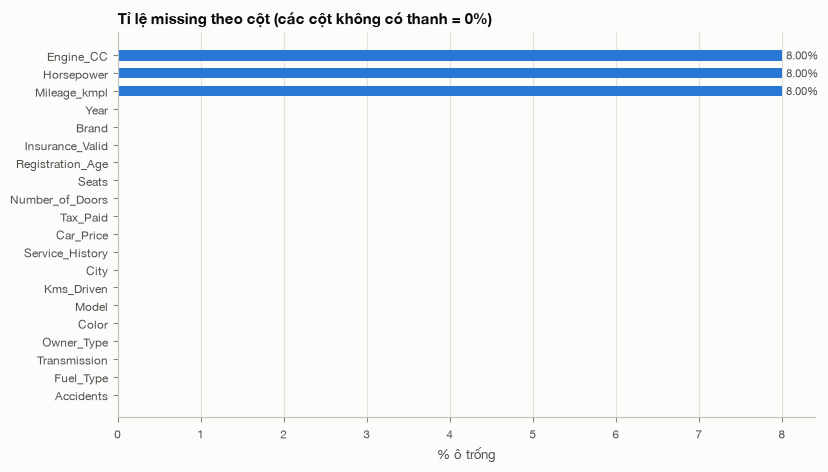

In [15]:
m = miss.sort_values("pct_missing")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(m.index, m.pct_missing, color=[C1 if v > 0 else GREY for v in m.pct_missing], height=0.6)
for y, v in enumerate(m.pct_missing):
    if v > 0:
        ax.annotate(f"{v:.2f}%", (v, y), xytext=(3, 0), textcoords="offset points", va="center", fontsize=8, color=INK2)
ax.set_xlabel("% ô trống")
ax.set_title("Tỉ lệ missing theo cột (các cột không có thanh = 0%)")
ax.grid(axis="y", visible=False)
plt.show()

> 💬 **Nhận xét:** Ba cột có missing đều ở mức gần như bằng nhau (khoảng 8%), đúng với ghi chú "missing values are addressed by the randomising script" trên sheet Dataset.

Mẫu hình missing: các cột có hay bị thiếu **cùng lúc** không? So sánh số dòng thực tế với số dòng kỳ vọng nếu mỗi cột thiếu độc lập.

In [16]:
MISS_COLS = miss.index[miss.n_missing > 0].tolist()
p_miss = df_raw[MISS_COLS].isnull().mean()
pattern = df_raw[MISS_COLS].isnull().value_counts().rename("n_rows").reset_index()
pattern["kỳ vọng nếu độc lập"] = pattern[MISS_COLS].apply(
    lambda r: len(df_raw) * np.prod([p_miss[c] if r[c] else 1 - p_miss[c] for c in MISS_COLS]), axis=1).round(0)
has_nan = df_raw[MISS_COLS].isnull().any(axis=1)
print(f"Số dòng có >= 1 NaN: {has_nan.sum():,} ({has_nan.mean() * 100:.2f}%)")
pattern

Số dòng có >= 1 NaN: 222,503 (22.14%)


,Engine_CC,Horsepower,Mileage_kmpl,n_rows,kỳ vọng nếu độc lập
0,False,False,False,782497,"782,585.000"
1,False,False,True,68243,"68,042.000"
2,True,False,False,68078,"68,054.000"
3,False,True,False,68004,"68,054.000"
4,True,True,False,6031,"5,918.000"
5,False,True,True,5853,"5,917.000"
6,True,False,True,5779,"5,917.000"
7,True,True,True,515,515.000


> 💬 **Nhận xét:** 222,503 dòng (22.14%) có ít nhất 1 NaN. Số dòng thực tế của từng tổ hợp missing **khớp gần tuyệt đối** với kỳ vọng nếu mỗi cột thiếu độc lập: thiếu cả 3 cột có 515 dòng, kỳ vọng 515; thiếu 2 cột có 5,779–6,031 dòng, kỳ vọng khoảng 5,917. Đây là dấu hiệu missing kiểu **MCAR-like** (hoàn toàn ngẫu nhiên).

### 3.2 'Unknown' và các biến thể

Với mỗi cột text, đếm số ô khớp **chính xác** với từng token 'Unknown', 'unknown', 'UNKNOWN', 'N/A', 'NA', '-', '', ' ', 'None', 'null'. Ngoài ra đếm thêm các biến thể 'unknown' sau khi strip và lower, và các ô chỉ chứa khoảng trắng.

In [17]:
UNKNOWN_TOKENS = ["Unknown", "unknown", "UNKNOWN", "N/A", "NA", "-", "", " ", "None", "null"]


def check_unknown(df, cols, tokens=UNKNOWN_TOKENS):
    """Bảng đếm token 'unknown' theo cột (tách riêng khỏi NaN thật)."""
    out = {}
    for c in cols:
        s = df[c]
        row = {repr(t): int((s == t).sum()) for t in tokens}
        row["strip+lower=='unknown'"] = int((s.str.strip().str.lower() == "unknown").sum())
        row["chỉ khoảng trắng"] = int((s.str.strip() == "").sum())
        row["NaN thật"] = int(s.isnull().sum())
        out[c] = row
    return pd.DataFrame(out).T


unk = check_unknown(df_raw, CAT_COLS)
unk

,'Unknown','unknown','UNKNOWN','N/A','NA','-','',' ','None','null',strip+lower=='unknown',chỉ khoảng trắng,NaN thật
Brand,0,0,0,0,0,0,0,0,0,0,0,0,0
Model,0,0,0,0,0,0,0,0,0,0,0,0,0
Fuel_Type,78733,0,0,0,0,0,0,0,0,0,78733,0,0
Transmission,80385,0,0,0,0,0,0,0,0,0,80385,0,0
Color,80419,0,0,0,0,0,0,0,0,0,80419,0,0
City,80430,0,0,0,0,0,0,0,0,0,80430,0,0
Owner_Type,0,0,0,0,0,0,0,0,0,0,0,0,0


> 💬 **Nhận xét:** Chỉ có đúng một dạng: 'Unknown' viết hoa chữ đầu, xuất hiện ở 4 cột (Fuel_Type 78,733, Transmission 80,385, Color 80,419, City 80,430). **Không có** 'unknown', 'N/A', '-', ô rỗng, 'None' hay 'null', và các cột text không có NaN thật.

Tổng hợp: bao nhiêu dòng có ít nhất một 'Unknown', và bao nhiêu dòng có NaN **hoặc** 'Unknown'?

In [18]:
UNK_COLS = unk.index[unk["'Unknown'"] > 0].tolist()
is_unknown = df_raw[UNK_COLS].eq("Unknown")
has_unk = is_unknown.any(axis=1)
n = len(df_raw)
print("Cột có 'Unknown':", UNK_COLS)
print(f"% 'Unknown' theo cột: {(is_unknown.mean() * 100).round(3).to_dict()}")
print(f"Dòng có >= 1 'Unknown': {has_unk.sum():,} ({has_unk.mean() * 100:.2f}%)"
      f" | kỳ vọng nếu độc lập: {(1 - (1 - is_unknown.mean()).prod()) * 100:.2f}%")
print("Phân bố số 'Unknown' trên một dòng:", is_unknown.sum(axis=1).value_counts().sort_index().to_dict())
print(f"Dòng có NaN HOẶC 'Unknown': {(has_nan | has_unk).sum():,} ({(has_nan | has_unk).mean() * 100:.2f}%)"
      f" -> nếu listwise deletion chỉ còn {n - (has_nan | has_unk).sum():,} dòng")

Cột có 'Unknown': ['Fuel_Type', 'Transmission', 'Color', 'City']
% 'Unknown' theo cột: {'Fuel_Type': 7.834, 'Transmission': 7.999, 'Color': 8.002, 'City': 8.003}
Dòng có >= 1 'Unknown': 283,648 (28.22%) | kỳ vọng nếu độc lập: 28.23%
Phân bố số 'Unknown' trên một dòng: {0: 721352, 1: 249283, 2: 32452, 3: 1872, 4: 41}
Dòng có NaN HOẶC 'Unknown': 443,543 (44.13%) -> nếu listwise deletion chỉ còn 561,457 dòng


> 💬 **Nhận xét:** 283,648 dòng (28.22%) có ít nhất 1 'Unknown'. Con số này bằng đúng kỳ vọng 28.23% nếu các cột độc lập, nên 'Unknown' cũng ngẫu nhiên như NaN. Gộp lại, **443,543 dòng (44.13%)** có NaN hoặc 'Unknown'; nếu listwise deletion thì chỉ còn 561,457 dòng.

### 3.3 Nhãn category không thống nhất

Chạy `value_counts(dropna=False)` cho từng cột categorical. Nhãn được in bằng `repr()` để thấy khoảng trắng thừa; cột nhiều nhãn chỉ hiện top 15.

In [19]:
def show_value_counts(df, col, top=15):
    vc = df[col].value_counts(dropna=False)
    shown = ", ".join(f"{k!r}: {v:,}" for k, v in vc.head(top).items())
    more = f"  … (+{len(vc) - top} nhãn khác)" if len(vc) > top else ""
    print(f"{col} — {len(vc)} nhãn:\n  {shown}{more}\n")


for c in CAT_COLS:
    show_value_counts(df_raw, c)

Brand — 26 nhãn:
  'BMW': 76,773, 'Skoda': 76,762, 'Hyundai': 76,750, 'Ford': 76,694, 'Toyota': 76,630, 'Audi': 76,573, 'Honda': 76,542, 'Kia': 76,524, 'Mercedes': 76,492, 'Volkswagen': 76,441, 'Mahindra': 76,308, 'Tata': 76,297, 'Nissan': 76,174, ' Mercedes ': 813, ' Nissan ': 792  … (+11 nhãn khác)

Model — 39 nhãn:
  'Verna': 26,046, 'Octavia': 26,008, 'Camry': 25,976, '3 Series': 25,975, 'Amaze': 25,950, 'Figo': 25,942, 'Kushaq': 25,939, 'EcoSport': 25,922, 'A4': 25,919, 'i20': 25,880, 'E-Class': 25,871, 'Magnite': 25,850, 'Carens': 25,819, 'Virtus': 25,809, 'Q3': 25,807  … (+24 nhãn khác)

Fuel_Type — 12 nhãn:
  'Petrol': 407,577, 'Diesel': 272,056, 'CNG': 90,628, 'Unknown': 78,733, 'Electric': 72,513, 'Hybrid': 63,370, 'hybridd': 3,423, ' Diesel': 3,390, 'diesel ': 3,373, 'petrol': 3,351, 'PETROL': 3,317, 'electrik': 3,269

Transmission — 3 nhãn:
  'Manual': 600,630, 'Automatic': 323,985, 'Unknown': 80,385

Color — 8 nhãn:
  'Red': 132,535, 'Blue': 132,306, 'Black': 132,298, 'Whi

> 💬 **Nhận xét:** Brand có 13 nhãn chuẩn (mỗi nhãn khoảng 76.2–76.8 nghìn dòng) và 13 biến thể có khoảng trắng (733–813 dòng). Fuel_Type có các biến thể `'hybridd'`, `' Diesel'`, `'diesel '`, `'petrol'`, `'PETROL'`, `'electrik'`. Model, Transmission, Color, City, Owner_Type không có biến thể; số dòng giữa các nhóm gần như bằng nhau.

So sánh số nhãn unique **trước và sau** `.str.strip().str.lower()`. Nếu số nhãn giảm sau khi chuẩn hóa thì cột đó có biến thể do khoảng trắng hoặc hoa/thường.

In [20]:
def norm(s):
    return s.str.strip().str.lower()


label_check = pd.DataFrame({"n_unique_raw": df_raw[CAT_COLS].nunique(),
                            "n_unique_strip_lower": df_raw[CAT_COLS].apply(lambda s: norm(s).nunique())})
label_check["số nhãn thừa"] = label_check.n_unique_raw - label_check.n_unique_strip_lower
label_check

,n_unique_raw,n_unique_strip_lower,số nhãn thừa
Brand,26,13,13
Model,39,39,0
Fuel_Type,12,8,4
Transmission,3,3,0
Color,8,8,0
City,9,9,0
Owner_Type,4,4,0


> 💬 **Nhận xét:** Sau `strip().lower()`, **Brand giảm từ 26 xuống 13 nhãn** và **Fuel_Type giảm từ 12 xuống 8 nhãn**; 5 cột còn lại không đổi. Fuel_Type vẫn còn 8 nhãn (thay vì 6) vì còn 2 lỗi chính tả mà strip/lower không sửa được.

Liệt kê các nhóm biến thể, tức những nhãn gốc khác nhau nhưng giống nhau sau khi strip và lower.

In [21]:
def variant_groups(s):
    vc = s.value_counts()
    t = pd.DataFrame({"raw": vc.index, "n": vc.values})
    t["key"] = norm(t["raw"])
    g = t.groupby("key").filter(lambda x: len(x) > 1)
    return (g.groupby("key")
             .apply(lambda x: pd.Series({"các nhãn gốc (repr: n)": ", ".join(f"{r!r}: {k:,}" for r, k in zip(x.raw, x.n)),
                                         "n_rows_biến_thể": int(x.n.iloc[1:].sum())}), include_groups=False))


for c in label_check.index[label_check["số nhãn thừa"] > 0]:
    print(f"== {c} ==")
    display(variant_groups(df_raw[c]))

== Brand ==


,các nhãn gốc (repr: n),n_rows_biến_thể
key,,
audi,"'Audi': 76,573, ' Audi ': 733",733
bmw,"'BMW': 76,773, ' BMW ': 788",788
ford,"'Ford': 76,694, ' Ford ': 745",745
honda,"'Honda': 76,542, ' Honda ': 770",770
hyundai,"'Hyundai': 76,750, ' Hyundai ': 767",767
kia,"'Kia': 76,524, ' Kia ': 769",769
mahindra,"'Mahindra': 76,308, ' Mahindra ': 785",785
mercedes,"'Mercedes': 76,492, ' Mercedes ': 813",813
nissan,"'Nissan': 76,174, ' Nissan ': 792",792


== Fuel_Type ==


,các nhãn gốc (repr: n),n_rows_biến_thể
key,,
diesel,"'Diesel': 272,056, ' Diesel': 3,390, 'diesel ': 3,373",6763
petrol,"'Petrol': 407,577, 'petrol': 3,351, 'PETROL': 3,317",6668


> 💬 **Nhận xét:** Mỗi Brand có đúng 1 biến thể dạng `' Brand '` (có khoảng trắng hai bên), tổng cộng 10,040 dòng. Fuel_Type có 2 biến thể của Diesel (6,763 dòng) và 2 biến thể của Petrol (6,668 dòng).

Tìm lỗi chính tả: với các nhãn hiếm (< 1% sau strip và lower), tìm nhãn phổ biến gần giống nhất bằng `difflib` (ngưỡng similarity ≥ 0.8).

In [22]:
def find_typos(s, cutoff=0.8, rare=0.01):
    keys = norm(s).value_counts()
    share = keys / keys.sum()
    common = share[share >= rare].index.tolist()
    rows = []
    for k, cnt in keys[share < rare].items():
        m = difflib.get_close_matches(k, common, n=1, cutoff=cutoff)
        if m:
            rows.append({"nhãn hiếm": k, "gần giống": m[0], "n_rows": int(cnt),
                         "similarity": round(difflib.SequenceMatcher(None, k, m[0]).ratio(), 3)})
    return pd.DataFrame(rows)


typos = pd.concat({c: find_typos(df_raw[c]) for c in CAT_COLS}, names=["column", "#"])
typos["n_rows"] = typos["n_rows"].astype(int)
typos

nhãn hiếm gần giống  n_rows  similarity
column    #                                        
Fuel_Type 0   hybridd    hybrid    3423       0.923
          1  electrik  electric    3269       0.875

> 💬 **Nhận xét:** `'hybridd'` gần giống `hybrid` (similarity 0.923, 3,423 dòng), `'electrik'` gần giống `electric` (0.875, 3,269 dòng). Ngoài 2 lỗi này không còn nhãn hiếm nào khác gần giống một nhãn phổ biến.

In riêng **mọi biến thể của Audi, BMW và Mercedes**, vì các biến thể này quyết định việc gán Luxury. Dùng regex không phân biệt hoa/thường để bắt cả các kiểu viết lạ như 'merc' hay 'benz'.

In [23]:
lux_like = df_raw["Brand"].str.contains(r"audi|bmw|merc|benz", case=False, regex=True)
lux_variants = df_raw.loc[lux_like, "Brand"].value_counts().rename("n_rows")
lux_variants.index = [repr(i) for i in lux_variants.index]
print(f"Luxury nếu so khớp CHÍNH XÁC nhãn gốc: {df_raw['Brand'].isin(LUXURY).sum():,} dòng"
      f" | nếu TRIM trước: {df_raw['Brand'].str.strip().isin(LUXURY).sum():,} dòng")
lux_variants.to_frame()

Luxury nếu so khớp CHÍNH XÁC nhãn gốc: 229,838 dòng | nếu TRIM trước: 232,172 dòng


,n_rows
'BMW',76773
'Audi',76573
'Mercedes',76492
' Mercedes ',813
' BMW ',788
' Audi ',733


> 💬 **Nhận xét:** Chỉ có 3 biến thể là `' Audi '` 733, `' BMW '` 788, `' Mercedes '` 813; không có kiểu viết như 'Merc' hay 'Benz'. So khớp nhãn gốc chính xác cho 229,838 xe Luxury, còn TRIM trước thì được 232,172, nên **2,334 xe Luxury sẽ bị xếp nhầm vào Non-luxury nếu không TRIM**.

### 3.4 Bản làm việc `df_eda`: thêm cột tạm, `df_raw` giữ nguyên

Để phân tích theo segment ở các mục sau, notebook tạo **các cột tạm** dựa trên mapping chuẩn hóa sơ bộ. Mapping này **mới chỉ là đề xuất**, bạn sẽ quyết định chính thức ở Mục 10.
- `Brand_std` = `Brand.str.strip()`
- `Fuel_std` = strip, lower, sửa typo (`hybridd`→hybrid, `electrik`→electric), rồi viết hoa theo dạng chuẩn
- `Segment` = Luxury nếu `Brand_std` ∈ {Audi, BMW, Mercedes}, còn lại là Non-luxury

Tạo `df_eda` và in bảng mapping đã dùng.

In [24]:
FUEL_TYPO_MAP = {"hybridd": "hybrid", "electrik": "electric"}
FUEL_CANON = {"petrol": "Petrol", "diesel": "Diesel", "cng": "CNG", "electric": "Electric",
              "hybrid": "Hybrid", "unknown": "Unknown"}

df_eda = df_raw.copy()
df_eda["Brand_std"] = df_raw["Brand"].str.strip()
df_eda["Fuel_std"] = norm(df_raw["Fuel_Type"]).replace(FUEL_TYPO_MAP).map(FUEL_CANON)
df_eda["Segment"] = np.where(df_eda["Brand_std"].isin(LUXURY), "Luxury", "Non-luxury")
assert df_eda["Fuel_std"].notna().all()

fuel_map = df_eda.groupby(["Fuel_Type", "Fuel_std"]).size().rename("n_rows").reset_index()
fuel_map["Fuel_Type"] = fuel_map["Fuel_Type"].map(repr)
brand_map = df_eda.groupby(["Brand", "Brand_std", "Segment"]).size().rename("n_rows").reset_index()
brand_map["Brand"] = brand_map["Brand"].map(repr)
display(fuel_map.sort_values(["Fuel_std", "n_rows"], ascending=[True, False]).reset_index(drop=True))
display(brand_map[brand_map.Segment == "Luxury"].reset_index(drop=True))
print("Segment (sau TRIM):", df_eda["Segment"].value_counts().to_dict(),
      "| % Luxury =", round((df_eda["Segment"] == "Luxury").mean() * 100, 3))

,Fuel_Type,Fuel_std,n_rows
0,'CNG',CNG,90628
1,'Diesel',Diesel,272056
2,' Diesel',Diesel,3390
3,'diesel ',Diesel,3373
4,'Electric',Electric,72513
5,'electrik',Electric,3269
6,'Hybrid',Hybrid,63370
7,'hybridd',Hybrid,3423
8,'Petrol',Petrol,407577
9,'petrol',Petrol,3351


,Brand,Brand_std,Segment,n_rows
0,' Audi ',Audi,Luxury,733
1,' BMW ',BMW,Luxury,788
2,' Mercedes ',Mercedes,Luxury,813
3,'Audi',Audi,Luxury,76573
4,'BMW',BMW,Luxury,76773
5,'Mercedes',Mercedes,Luxury,76492


Segment (sau TRIM): {'Non-luxury': 772828, 'Luxury': 232172} | % Luxury = 23.102


> 💬 **Nhận xét:** Mapping đưa 12 nhãn Fuel về 6 nhãn chuẩn, và 6 nhãn Luxury gốc về 3 hãng. Sau TRIM, Segment có Luxury = 232,172 dòng (23.10%) và Non-luxury = 772,828 dòng. `df_raw` không bị động tới.

### 3.5 Duplicated records

Đếm exact duplicates (trùng toàn bộ 20 cột). Dữ liệu không có cột ID, nên thay cho bước "bỏ cột ID" notebook kiểm tra near-duplicate theo hai cách: trùng mọi cột trừ `Car_Price`, và trùng sau khi chuẩn hóa nhãn.

In [25]:
n_dup = df_raw.duplicated().sum()
dup_all = df_raw.duplicated(keep=False)
print(f"df_raw.duplicated().sum() = {n_dup:,}  ({n_dup / len(df_raw) * 100:.3f}%)"
      f" | số dòng thuộc nhóm trùng = {dup_all.sum():,}")
print("Kích thước nhóm trùng:", df_raw[dup_all].groupby(df_raw.columns.tolist(), dropna=False).size().value_counts().to_dict())
print("Cột ID để bỏ khi so trùng: không có (ID_COLS = [])")
cols_no_price = [c for c in df_raw.columns if c != TARGET]
print(f"Near-duplicate: trùng mọi cột trừ Car_Price = {df_raw.duplicated(subset=cols_no_price).sum():,}")
std_cols = ["Brand_std", "Fuel_std"] + [c for c in df_raw.columns if c not in ("Brand", "Fuel_Type")]
print(f"Near-duplicate: trùng sau khi chuẩn hoá nhãn = {df_eda.duplicated(subset=std_cols).sum():,}")
print(f"Nếu bỏ bản sao thừa: còn {len(df_raw) - n_dup:,} dòng")

df_raw.duplicated().sum() = 5,000  (0.498%) | số dòng thuộc nhóm trùng = 10,000
Kích thước nhóm trùng: {2: 5000}
Cột ID để bỏ khi so trùng: không có (ID_COLS = [])
Near-duplicate: trùng mọi cột trừ Car_Price = 5,000


Near-duplicate: trùng sau khi chuẩn hoá nhãn = 5,000
Nếu bỏ bản sao thừa: còn 1,000,000 dòng


> 💬 **Nhận xét:** `duplicated().sum()` = **5,000** (0.498%). Tất cả nằm trong 5,000 cặp, mỗi cặp đúng 2 dòng. Hai kiểu near-duplicate (bỏ Car_Price, hoặc chuẩn hóa nhãn) đều không thêm dòng trùng nào mới. Bỏ bản sao thì còn **đúng 1,000,000 dòng**, nên nhiều khả năng các bản sao được chèn vào có chủ đích.

Xem ví dụ các dòng trùng, kèm số dòng tương ứng trong Excel (= index + 2).

In [26]:
dups = df_raw[dup_all].sort_values(df_raw.columns.tolist())
dups.insert(0, "excel_row", dups.index + 2)
pos = df_raw.index[df_raw.duplicated()] + 2
print(f"Vị trí (dòng Excel) của bản sao thừa: min {pos.min():,} – median {int(np.median(pos)):,} – max {pos.max():,}")
dups.head(6)

Vị trí (dòng Excel) của bản sao thừa: min 8,603 – median 564,727 – max 1,004,834


,excel_row,Brand,Model,Year,Mileage_kmpl,Engine_CC,Horsepower,Fuel_Type,Transmission,Owner_Type,Color,City,Kms_Driven,Insurance_Valid,Service_History,Accidents,Tax_Paid,Number_of_Doors,Seats,Registration_Age,Car_Price
5206,5208,Audi,A4,2022,20.030,"1,910.869",160.763,Diesel,Manual,First,Silver,Pune,32754,1,1,0,1,4,4,3,"1,961,441.582"
346515,346517,Audi,A4,2022,20.030,"1,910.869",160.763,Diesel,Manual,First,Silver,Pune,32754,1,1,0,1,4,4,3,"1,961,441.582"
91187,91189,Audi,Q3,2008,12.778,879.493,NaN,Diesel,Automatic,First,Silver,Hyderabad,110840,1,1,1,1,4,5,17,"2,544,484.861"
165808,165810,Audi,Q3,2008,12.778,879.493,NaN,Diesel,Automatic,First,Silver,Hyderabad,110840,1,1,1,1,4,5,17,"2,544,484.861"
39509,39511,Audi,Q3,2014,16.635,NaN,NaN,Petrol,Unknown,Second,Grey,Bangalore,189145,1,0,0,1,4,5,11,"1,869,571.722"
53426,53428,Audi,Q3,2014,16.635,NaN,NaN,Petrol,Unknown,Second,Grey,Bangalore,189145,1,0,0,1,4,5,11,"1,869,571.722"


> 💬 **Nhận xét:** Các cặp trùng giống nhau tới cả những số thực nhiều chữ số thập phân, ví dụ dòng Excel 5208 và 346517 (Audi A4 2022, Car_Price 1,961,441.582), nên không thể là trùng ngẫu nhiên. Bản sao nằm rải rác trong file (dòng Excel 8,603 → 1,004,834).

### 3.6 Giá trị không hợp lệ về logic (chỉ dựa trên logic nội tại của dữ liệu)

Kiểm tra các quy tắc: giá ≤ 0, giá trị âm, năm sản xuất sau năm listing, Year và Registration_Age có khớp nhau không, biến nhị phân có nằm ngoài {0, 1} không, v.v. Năm listing **không có sẵn** trong dữ liệu, nên notebook suy ra năm tham chiếu từ Year + Registration_Age.

In [27]:
year_plus_age = df_raw["Year"] + df_raw["Registration_Age"]
print("Year + Registration_Age:", year_plus_age.value_counts().to_dict())
REF_YEAR = int(year_plus_age.mode()[0])       # GIẢ ĐỊNH: năm tham chiếu (năm listing/thu thập)

rules = {
    "Car_Price <= 0": df_raw["Car_Price"] <= 0,
    "Kms_Driven <= 0": df_raw["Kms_Driven"] <= 0,
    "Mileage_kmpl <= 0": df_raw["Mileage_kmpl"] <= 0,
    "Engine_CC <= 0": df_raw["Engine_CC"] <= 0,
    "Horsepower <= 0": df_raw["Horsepower"] <= 0,
    "Có giá trị âm ở bất kỳ cột numeric nào": (df_raw[NUM_COLS] < 0).any(axis=1),
    f"Year > năm tham chiếu ({REF_YEAR})": df_raw["Year"] > REF_YEAR,
    f"Year + Registration_Age != {REF_YEAR}": year_plus_age != REF_YEAR,
    "Registration_Age <= 0": df_raw["Registration_Age"] <= 0,
    "Seats <= 0 hoặc Number_of_Doors <= 0": (df_raw["Seats"] <= 0) | (df_raw["Number_of_Doors"] <= 0),
    "Accidents < 0": df_raw["Accidents"] < 0,
    "Biến nhị phân ngoài {0, 1}": ~df_raw[BINARY].isin([0, 1]).all(axis=1),
}
logic = pd.DataFrame({"n_rows": {k: int(v.sum()) for k, v in rules.items()}})
logic["pct"] = logic["n_rows"] / len(df_raw) * 100
logic

Year + Registration_Age: {2025: 1005000}


,n_rows,pct
Car_Price <= 0,0,0.000
Kms_Driven <= 0,0,0.000
Mileage_kmpl <= 0,0,0.000
Engine_CC <= 0,0,0.000
Horsepower <= 0,32,0.003
Có giá trị âm ở bất kỳ cột numeric nào,32,0.003
Year > năm tham chiếu (2025),0,0.000
Year + Registration_Age != 2025,0,0.000
Registration_Age <= 0,0,0.000
Seats <= 0 hoặc Number_of_Doors <= 0,0,0.000


> 💬 **Nhận xét:** Year + Registration_Age = 2025 ở **100% dòng**, nên **GIẢ ĐỊNH năm tham chiếu là 2025**; không có xe nào sản xuất sau năm này. Vi phạm logic duy nhất là **Horsepower ≤ 0 ở 32 dòng** (0.003%), và đây cũng là các giá trị âm duy nhất trong cả bảng. Các biến nhị phân chỉ nhận giá trị 0 hoặc 1.

Kiểm tra "point mass", tức một giá trị lặp lại bất thường nhiều lần. Với biến continuous, gần như mọi giá trị đều unique, nên nếu giá trị **min** lặp lại hàng nghìn lần thì đó là dấu hiệu bị chặn sàn (censoring).

In [28]:
def min_point_mass(df, cols):
    rows = []
    for c in cols:
        s = df[c].dropna()
        vc = s.value_counts()
        rows.append({"variable": c, "min": s.min(), "n_at_min": int((s == s.min()).sum()),
                     "pct_at_min": (s == s.min()).mean() * 100, "giá trị lặp nhiều nhất": vc.index[0],
                     "n_lặp": int(vc.iloc[0]), "giá trị kế tiếp trên min": s[s > s.min()].min()})
    return pd.DataFrame(rows).set_index("variable")


pm = min_point_mass(df_raw, NUM_CONT)
PRICE_FLOOR = df_raw["Car_Price"].min()
pm

,min,n_at_min,pct_at_min,giá trị lặp nhiều nhất,n_lặp,giá trị kế tiếp trên min
variable,,,,,,
Mileage_kmpl,5.000,516,0.056,5.000,516,5.005
Engine_CC,800.000,37028,4.005,800.000,37028,800.008
Horsepower,-18.510,1,0.000,100.927,2,-17.709
Kms_Driven,"5,000.000",4,0.000,"117,600.000",38,"5,002.000"
Car_Price,"50,000.000",116375,11.580,"50,000.000",116375,"50,000.862"


> 💬 **Nhận xét:** **Car_Price = 50,000 ở 116,375 dòng (11.58%)**, trong khi giá trị kế tiếp là 50,000.86. Engine_CC = 800 ở 37,028 dòng (4.0%), Mileage_kmpl = 5 ở 516 dòng. Horsepower và Kms_Driven không có hiện tượng này (giá trị lặp nhiều nhất chỉ 2 và 38 lần). Min của 3 biến đầu vì vậy là **giá trị sàn** (censoring), không phải giá quan sát.

## 4. Phân tích từng biến (univariate)

### 4.1 Numeric

Chạy `describe()` với các percentile 1/5/25/50/75/95/99, thêm skewness và kurtosis (excess), tính trên toàn bộ dữ liệu thô. NaN được bỏ qua theo từng cột.

In [29]:
desc = df_raw[NUM_COLS].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
desc["skew"] = df_raw[NUM_COLS].skew()
desc["kurt"] = df_raw[NUM_COLS].kurt()
desc

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,kurt
Mileage_kmpl,"924,610.000",17.996,3.994,5.000,8.688,11.417,15.302,17.998,20.689,24.567,27.287,36.282,0.003,-0.022
Engine_CC,"924,597.000","1,506.627",386.034,800.000,800.000,841.991,"1,230.407","1,500.181","1,769.599","2,158.424","2,430.767","3,362.023",0.197,-0.317
Horsepower,"924,597.000",120.572,36.775,-18.510,40.651,61.039,94.841,120.053,145.478,182.122,207.651,290.250,0.113,-0.162
Kms_Driven,"1,005,000.000","202,863.890","175,370.541","5,000.000","10,053.000","21,704.950","84,555.000","166,313.000","286,380.000","478,764.200","588,480.240","4,368,000.000",4.643,56.980
Car_Price,"1,005,000.000","1,012,896.960","1,141,644.936","50,000.000","50,000.000","50,000.000","343,350.411","758,908.320","1,293,475.466","2,970,531.370","3,795,581.317","37,885,997.533",6.991,116.466
Year,"1,005,000.000","2,011.996",7.211,"2,000.000","2,000.000","2,001.000","2,006.000","2,012.000","2,018.000","2,023.000","2,024.000","2,024.000",0.001,-1.204
Registration_Age,"1,005,000.000",13.004,7.211,1.000,1.000,2.000,7.000,13.000,19.000,24.000,25.000,25.000,-0.001,-1.204
Accidents,"1,005,000.000",0.299,0.547,0.000,0.000,0.000,0.000,0.000,1.000,1.000,2.000,5.000,1.826,3.312
Number_of_Doors,"1,005,000.000",4.249,0.699,2.000,2.000,2.000,4.000,4.000,5.000,5.000,5.000,5.000,-1.267,2.864
Seats,"1,005,000.000",5.160,0.914,2.000,2.000,4.000,5.000,5.000,5.000,7.000,7.000,7.000,0.227,2.540


> 💬 **Nhận xét:** Car_Price: mean 1,012,897 lớn hơn median 758,908; P1 = P5 = 50,000 (giá sàn); P99 là 3.80M nhưng max tới 37.9M; skew 6.99, kurt 116.5, tức **lệch phải rất mạnh**. Kms_Driven: P99 588,480 nhưng max 4,368,000 (skew 4.64). Engine_CC có P1 = min = 800 (giá sàn), Horsepower có min −18.5. Year và Registration_Age phân bố đều (kurt −1.20).

Vẽ histogram và boxplot cho từng biến continuous. Với biến lệch mạnh (skew > 1), trục x của histogram được cắt ở P99.9 và tiêu đề ghi rõ điều này; boxplot vẫn hiển thị toàn bộ dữ liệu.

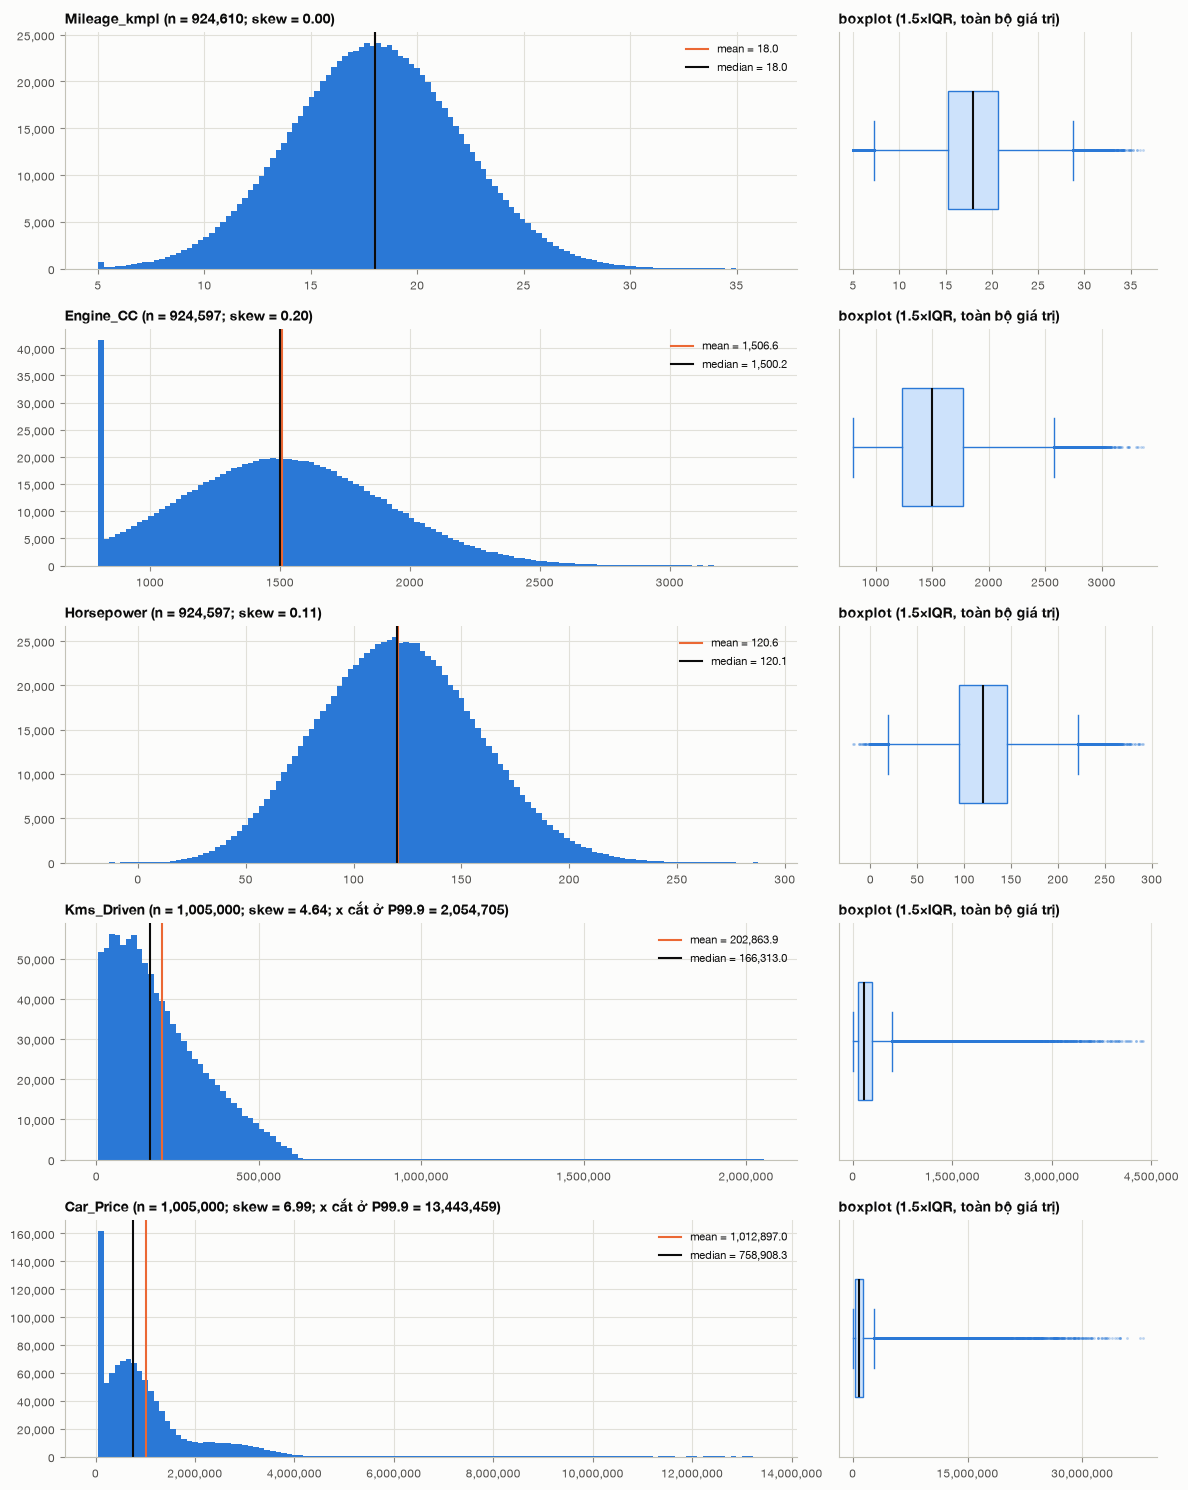

In [30]:
def plot_hist_box(s, ax_h, ax_b, bins=120):
    s = s.dropna()
    hi = s.quantile(0.999) if s.skew() > 1 else s.max()
    ax_h.hist(s[s <= hi], bins=bins, range=(s.min(), hi), color=C1, linewidth=0)
    ax_h.axvline(s.mean(), color=C2, linewidth=1.5, label=f"mean = {s.mean():,.1f}")
    ax_h.axvline(s.median(), color=INK, linewidth=1.5, label=f"median = {s.median():,.1f}")
    cut = f"; x cắt ở P99.9 = {hi:,.0f}" if hi < s.max() else ""
    ax_h.set_title(f"{s.name} (n = {len(s):,}; skew = {s.skew():.2f}{cut})", fontsize=10)
    ax_h.legend(loc="upper right", fontsize=8)
    thousands(ax_h)
    ax_b.boxplot(s, orientation="horizontal", widths=0.5, patch_artist=True,
                 boxprops=dict(facecolor="#cde2fb", edgecolor=C1), medianprops=dict(color=INK, linewidth=1.5),
                 whiskerprops=dict(color=C1), capprops=dict(color=C1),
                 flierprops=dict(marker="o", markersize=2, markerfacecolor=C1, markeredgecolor="none", alpha=0.3))
    ax_b.set_yticks([])
    ax_b.set_title("boxplot (1.5×IQR, toàn bộ giá trị)", fontsize=10)
    if s.max() > 10_000:
        thousands(ax_h, "x")
        thousands(ax_b, "x")
        ax_b.xaxis.set_major_locator(MaxNLocator(4))


fig, axes = plt.subplots(len(NUM_CONT), 2, figsize=(12, 3 * len(NUM_CONT)), gridspec_kw={"width_ratios": [2.3, 1]})
for i, c in enumerate(NUM_CONT):
    plot_hist_box(df_raw[c], axes[i, 0], axes[i, 1])
fig.tight_layout()
plt.show()

> 💬 **Nhận xét:** Thấy rõ các cột dồn ở 800 (Engine_CC), 5 (Mileage) và 50,000 (Car_Price). Car_Price có **2 "bướu"**, khoảng 0.7M và 2–3M, gợi ý hai segment. Kms_Driven có một đuôi dài sau khoảng 600k. Mileage, Engine và HP gần đối xứng (|skew| ≤ 0.2).

Vẽ bar chart cho các biến rời rạc và nhị phân (histogram không phù hợp vì các biến này có ít giá trị).

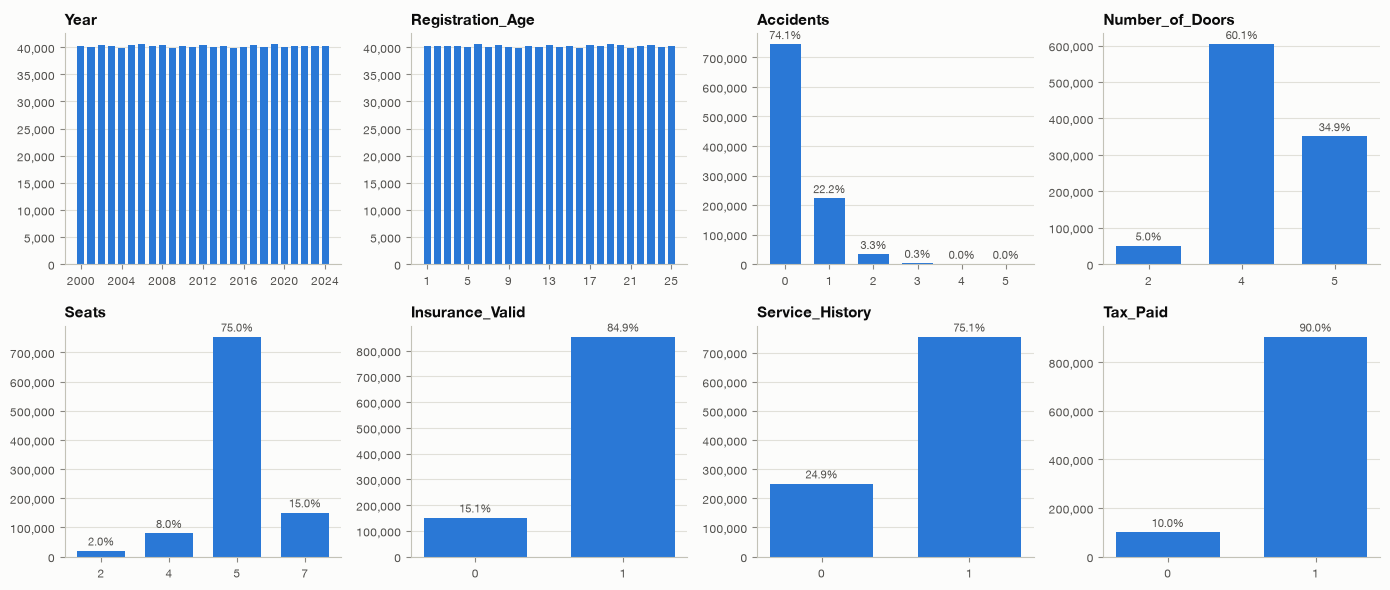

In [31]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, c in zip(axes.flat, NUM_DISC + BINARY):
    vc = df_raw[c].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color=C1, width=0.7)
    ax.set_title(c)
    thousands(ax)
    ax.grid(axis="x", visible=False)
    if len(vc) > 10:
        ax.set_xticks(range(0, len(vc), 4))
        ax.set_xticklabels(vc.index.astype(str)[::4])
    else:
        for x, y in zip(vc.index.astype(str), vc.values):
            ax.annotate(f"{y / len(df_raw) * 100:.1f}%", (x, y), ha="center", va="bottom", fontsize=8,
                        color=INK2, xytext=(0, 2), textcoords="offset points")
fig.tight_layout()
plt.show()

> 💬 **Nhận xét:** Year và Registration_Age **đều tuyệt đối**, khoảng 4% mỗi năm. Accidents: 74.1% không có vụ nào, 5 vụ gần như 0%. Cửa: 4 cửa chiếm 60.1%; chỗ ngồi: 5 chỗ chiếm 75.0%. Tỉ lệ bằng 1 của các biến nhị phân: Insurance 84.9%, Service 75.1%, Tax 90.0%.

### 4.2 Categorical

Chạy `value_counts()` và `value_counts(normalize=True)` cho từng biến categorical. Brand và Fuel_Type dùng nhãn đã chuẩn hóa sơ bộ (`Brand_std`, `Fuel_std`), vì biến thể gốc đã được xem ở 3.3. Kết quả gộp thành một bảng top 15 để dễ nhìn.

In [32]:
CAT_VIEW = {"Brand": "Brand_std", "Model": "Model", "Fuel_Type": "Fuel_std", "Transmission": "Transmission",
            "Owner_Type": "Owner_Type", "Color": "Color", "City": "City", "Segment": "Segment"}


def freq_table(s, top=15):
    cnt = s.value_counts()
    pct = s.value_counts(normalize=True) * 100
    return pd.Series([f"{k}: {v:,} ({p:.2f}%)" for (k, v), p in zip(cnt.items(), pct.values)][:top])


pd.DataFrame({name: freq_table(df_eda[col]) for name, col in CAT_VIEW.items()}).fillna("")

,Brand,Model,Fuel_Type,Transmission,Owner_Type,Color,City,Segment
0,"BMW: 77,561 (7.72%)","Verna: 26,046 (2.59%)","Petrol: 414,245 (41.22%)","Manual: 600,630 (59.76%)","First: 602,365 (59.94%)","Red: 132,535 (13.19%)","Delhi: 115,999 (11.54%)","Non-luxury: 772,828 (76.90%)"
1,"Skoda: 77,551 (7.72%)","Octavia: 26,008 (2.59%)","Diesel: 278,819 (27.74%)","Automatic: 323,985 (32.24%)","Second: 251,715 (25.05%)","Blue: 132,306 (13.16%)","Hyderabad: 115,854 (11.53%)","Luxury: 232,172 (23.10%)"
2,"Hyundai: 77,517 (7.71%)","Camry: 25,976 (2.58%)","CNG: 90,628 (9.02%)","Unknown: 80,385 (8.00%)","Third: 100,653 (10.02%)","Black: 132,298 (13.16%)","Mumbai: 115,777 (11.52%)",
3,"Ford: 77,439 (7.71%)","3 Series: 25,975 (2.58%)","Unknown: 78,733 (7.83%)",,"Fourth+: 50,267 (5.00%)","White: 132,027 (13.14%)","Pune: 115,588 (11.50%)",
4,"Toyota: 77,397 (7.70%)","Amaze: 25,950 (2.58%)","Electric: 75,782 (7.54%)",,,"Brown: 131,985 (13.13%)","Ahmedabad: 115,480 (11.49%)",
5,"Honda: 77,312 (7.69%)","Figo: 25,942 (2.58%)","Hybrid: 66,793 (6.65%)",,,"Grey: 131,932 (13.13%)","Bangalore: 115,471 (11.49%)",
6,"Audi: 77,306 (7.69%)","Kushaq: 25,939 (2.58%)",,,,"Silver: 131,498 (13.08%)","Kolkata: 115,405 (11.48%)",
7,"Mercedes: 77,305 (7.69%)","EcoSport: 25,922 (2.58%)",,,,"Unknown: 80,419 (8.00%)","Chennai: 114,996 (11.44%)",
8,"Kia: 77,293 (7.69%)","A4: 25,919 (2.58%)",,,,,"Unknown: 80,430 (8.00%)",
9,"Volkswagen: 77,185 (7.68%)","i20: 25,880 (2.58%)",,,,,,


> 💬 **Nhận xét:** Brand (7.66–7.72%), Model (2.54–2.59%), City (11.44–11.54%, cộng Unknown 8%) và Color (13.08–13.19%, cộng Unknown 8%) **gần như đều tuyệt đối**. Chỉ Fuel (Petrol 41.2%), Transmission (Manual 59.8%) và Owner (First 59.9%) là mất cân bằng.

Đếm số nhóm hiếm (< 1% số dòng), tính cho cả nhãn gốc lẫn nhãn đã chuẩn hóa.

In [33]:
def rare_summary(s, thr=0.01):
    share = s.value_counts(normalize=True)
    rare = share[share < thr]
    return pd.Series({"n_groups": len(share), "n_rare(<1%)": len(rare),
                      "nhóm hiếm": ", ".join(repr(x) for x in rare.index[:8]) + (" …" if len(rare) > 8 else "")})


rare_tab = pd.concat({"raw": pd.DataFrame({c: rare_summary(df_raw[c]) for c in CAT_COLS}).T,
                      "chuẩn hoá": pd.DataFrame({c: rare_summary(df_eda[v]) for c, v in CAT_VIEW.items()
                                                 if c != "Segment"}).T}, axis=1)
rare_tab

raw                                                                          chuẩn hoá                      
             n_groups n_rare(<1%)                                                    nhóm hiếm  n_groups n_rare(<1%) nhóm hiếm
Brand              26          13  ' Mercedes ', ' Nissan ', ' Skoda ', ' BMW ', ' Mahindra...        13           0          
Model              39           0                                                                     39           0          
Fuel_Type          12           6  'hybridd', ' Diesel', 'diesel ', 'petrol', 'PETROL', 'el...         6           0          
Transmission        3           0                                                                      3           0          
Color               8           0                                                                      8           0          
City                9           0                                                                      9           0          
Owner_Type          4           0                                                                      4           0

> 💬 **Nhận xét:** Với nhãn gốc có **19 nhóm hiếm (< 1%)**: 13 ở Brand và 6 ở Fuel_Type, và tất cả đều là biến thể lỗi. Sau chuẩn hóa sơ bộ thì không còn nhóm hiếm nào.

Vẽ bar chart top 15 cho từng biến categorical, dùng nhãn đã chuẩn hóa. Các cột 'Unknown' được tô xám.

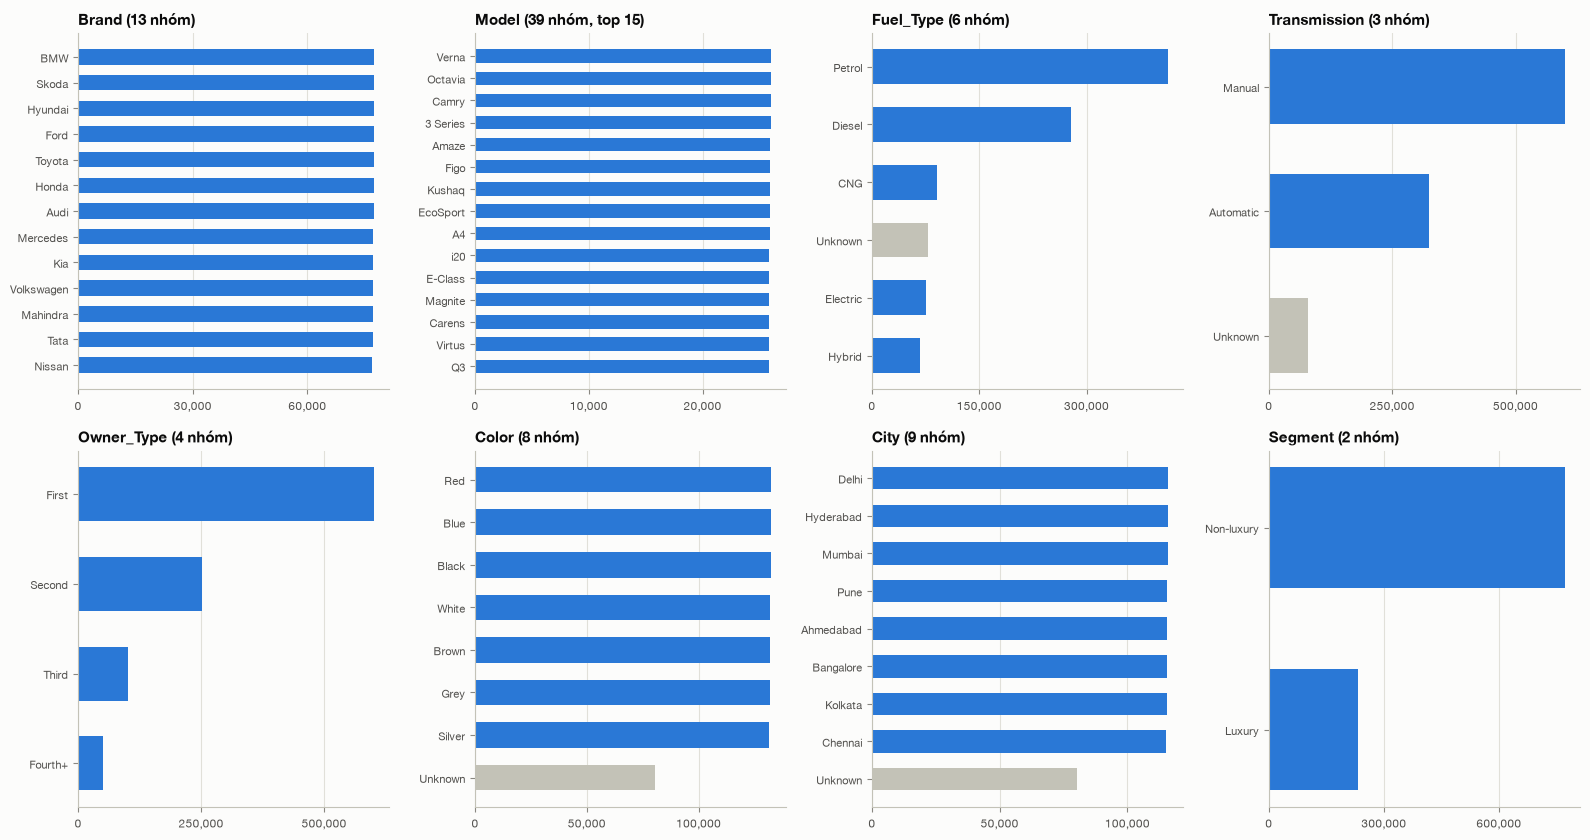

In [34]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
for ax, (name, col) in zip(axes.flat, CAT_VIEW.items()):
    vc = df_eda[col].value_counts().head(15)
    if name == "Owner_Type":
        vc = vc.reindex(["First", "Second", "Third", "Fourth+"])
    vc = vc.iloc[::-1]
    ax.barh([str(i) for i in vc.index], vc.values, height=0.6,
            color=[GREY if i == "Unknown" else C1 for i in vc.index])
    ax.set_title(f"{name} ({df_eda[col].nunique()} nhóm{', top 15' if df_eda[col].nunique() > 15 else ''})")
    ax.xaxis.set_major_locator(MaxNLocator(3))
    thousands(ax, "x")
    ax.grid(axis="y", visible=False)
    ax.tick_params(axis="y", labelsize=8)
fig.tight_layout()
plt.show()

> 💬 **Nhận xét:** Các biểu đồ xác nhận: 'Unknown' (màu xám) chiếm khoảng 8% ở Fuel, Transmission, Color và City; Segment có tỉ lệ Non-luxury : Luxury khoảng 3.3 : 1.

## 5. Phân tích ngoại lệ (outliers)

### 5.1 IQR rule (1.5× và 3×) vs z-score (|z| > 3)

Đếm số outlier và % theo từng cách cho mọi biến numeric (không tính biến nhị phân). Hai biến lệch mạnh được tính thêm trên thang log1p.

In [35]:
def outlier_table(df, cols):
    rows = []
    for c in cols:
        s = df[c].dropna()
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        z = (s - s.mean()) / s.std()
        n15 = int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())
        n3 = int(((s < q1 - 3 * iqr) | (s > q3 + 3 * iqr)).sum())
        nz = int((z.abs() > 3).sum())
        rows.append({"variable": c, "n": len(s), "IQR": iqr, "fence_low_1.5": q1 - 1.5 * iqr,
                     "fence_high_1.5": q3 + 1.5 * iqr, "n_1.5IQR": n15, "%_1.5IQR": n15 / len(s) * 100,
                     "n_3IQR": n3, "%_3IQR": n3 / len(s) * 100, "n_|z|>3": nz, "%_|z|>3": nz / len(s) * 100})
    return pd.DataFrame(rows).set_index("variable")


log_view = pd.DataFrame({"log1p(Car_Price)": np.log1p(df_raw["Car_Price"]),
                         "log1p(Kms_Driven)": np.log1p(df_raw["Kms_Driven"])})
out_tab = pd.concat([outlier_table(df_raw, NUM_CONT + NUM_DISC), outlier_table(log_view, log_view.columns)])
out_tab

,n,IQR,fence_low_1.5,fence_high_1.5,n_1.5IQR,%_1.5IQR,n_3IQR,%_3IQR,n_|z|>3,%_|z|>3
variable,,,,,,,,,,
Mileage_kmpl,924610,5.387,7.220,28.770,6505,0.704,0,0.000,2484,0.269
Engine_CC,924597,539.192,421.619,"2,578.387",3223,0.349,0,0.000,1647,0.178
Horsepower,924597,50.637,18.885,221.434,4005,0.433,0,0.000,1708,0.185
Kms_Driven,1005000,"201,825.000","-218,182.500","589,117.500",9948,0.990,4431,0.441,5307,0.528
Car_Price,1005000,"950,125.054","-1,081,837.170","2,718,663.047",70413,7.006,5843,0.581,4780,0.476
Year,1005000,12.000,"1,988.000","2,036.000",0,0.000,0,0.000,0,0.000
Registration_Age,1005000,12.000,-11.000,37.000,0,0.000,0,0.000,0,0.000
Accidents,1005000,1.000,-1.500,2.500,3633,0.361,16,0.002,37067,3.688
Number_of_Doors,1005000,1.000,2.500,6.500,50514,5.026,0,0.000,50514,5.026


> 💬 **Nhận xét:** Với Car_Price, rule 1.5×IQR gắn cờ **7.01%** số dòng, 3×IQR gắn 0.58%, z-score gắn 0.48%; trên thang log1p, 1.5×IQR chỉ còn 0.18%. IQR **không phù hợp với biến rời rạc**: Seats có IQR = 0 nên 25.0% số dòng bị gắn cờ, Doors 5.0%. z-score gắn cờ mọi xe có ≥ 2 tai nạn (3.69%). Vì vậy không nên xóa dữ liệu chỉ dựa trên một ngưỡng thống kê.

### 5.2 Tách *implausible* với *extreme nhưng có thể hợp lệ*

- **(a) Implausible:** giá trị vi phạm logic nội tại của dữ liệu. Ví dụ Horsepower ≤ 0, hoặc Kms_Driven > 1,000,000 (ví dụ do chính Assessment Guide nêu).
- **(b) Extreme nhưng có thể hợp lệ:** vượt ngưỡng thống kê nhưng không vi phạm quy tắc nào.
- **(c) Giá trị sàn (censored):** point mass tại min (xem 3.6). Loại này không phải outlier theo IQR, nhưng làm méo phân phối.

Đuôi phải của Kms_Driven: số km có tỉ lệ thuận với tuổi xe không? Tính **km mỗi năm tuổi** = Kms_Driven / Registration_Age và xem phân phối của nó.

In [36]:
df_eda["km_per_year"] = df_raw["Kms_Driven"] / df_raw["Registration_Age"]
kpy = df_eda["km_per_year"]
print(kpy.describe(percentiles=[.001, .5, .99, .994, .995, .999]).to_string(), "\n")
kpy_bins = pd.cut(kpy, [0, 5_000, 25_000, 30_000, 50_000, 100_000, np.inf], right=False)
kpy_bins.value_counts().sort_index().rename("n_rows").to_frame().assign(pct=lambda t: t.n_rows / len(kpy) * 100)

count   1,005,000.000
mean       15,599.951
std         9,087.257
min         5,000.000
0.1%        5,019.000
50%        15,095.000
99%        24,990.000
99.4%      60,170.012
99.5%      69,252.090
99.9%     130,212.016
max       174,951.000 



,n_rows,pct
km_per_year,,
"[0.0, 5000.0)",0,0.000
"[5000.0, 25000.0)",995377,99.042
"[25000.0, 30000.0)",396,0.039
"[30000.0, 50000.0)",2098,0.209
"[50000.0, 100000.0)",4693,0.467
"[100000.0, inf)",2436,0.242


> 💬 **Nhận xét:** **99.04% dòng có km/năm nằm trong [5,000; 25,000)**, với median 15,095. P99 = 24,990 nhưng P99.4 đã nhảy lên 60,170. Có 9,623 dòng (0.96%) từ 25,000 km/năm trở lên.

Vẽ hai histogram trên thang log: Kms_Driven kèm ngưỡng 1,000,000 km của Guide, và km/năm kèm biên 25,000.

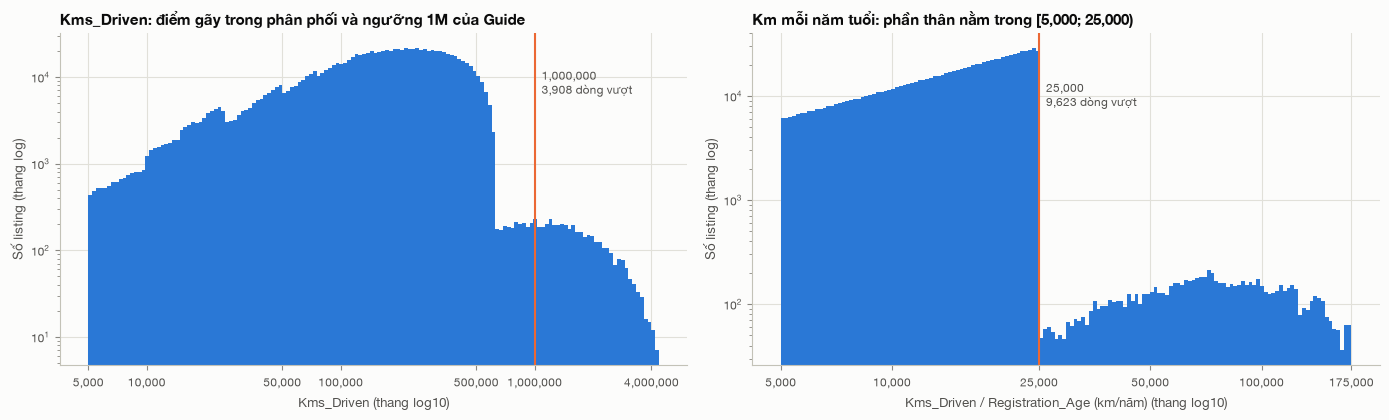

In [37]:
KPY_MAX, KMS_GUIDE = 25_000, 1_000_000
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
for ax, s, line, lab, ticks in [
        (axes[0], df_raw["Kms_Driven"], KMS_GUIDE, "Kms_Driven", [5e3, 1e4, 5e4, 1e5, 5e5, 1e6, 4e6]),
        (axes[1], kpy, KPY_MAX, "Kms_Driven / Registration_Age (km/năm)", [5e3, 1e4, 2.5e4, 5e4, 1e5, 1.75e5])]:
    ax.hist(np.log10(s), bins=150, color=C1, linewidth=0)
    ax.set_yscale("log")
    ax.axvline(np.log10(line), color=C2, linewidth=1.5)
    ax.annotate(f"{line:,.0f}\n{(s > line).sum():,} dòng vượt", (np.log10(line), ax.get_ylim()[1] * 0.2),
                xytext=(5, 0), textcoords="offset points", fontsize=8.5, color=INK2)
    ax.set_xticks(np.log10(ticks))
    ax.set_xticklabels([f"{t:,.0f}" for t in ticks])
    ax.set_xlabel(lab + " (thang log10)")
    ax.set_ylabel("Số listing (thang log)")
axes[0].set_title("Kms_Driven: điểm gãy trong phân phối và ngưỡng 1M của Guide")
axes[1].set_title("Km mỗi năm tuổi: phần thân nằm trong [5,000; 25,000)")
fig.tight_layout()
plt.show()

> 💬 **Nhận xét:** Histogram Kms_Driven có **điểm gãy rõ ở khoảng 600k**: mật độ giảm khoảng 100 lần, sau đó là một nhóm phẳng kéo dài tới 4.4M. Ngưỡng 1M của Guide cắt ngang **giữa** nhóm bất thường này. Histogram km/năm có một biên sắc ở 25,000, và phần vượt biên là một nhóm tách rời hẳn.

Nhóm có km/năm > 25,000 có gì khác về **giá** không? Để trả lời, so giá của mỗi xe với median giá của các xe **cùng Model và cùng tuổi** (median tham chiếu tính trên phần thân dữ liệu, không tính các dòng ở giá sàn).

In [38]:
over = kpy > KPY_MAX
ref_mask = ~over & (df_raw["Car_Price"] > PRICE_FLOOR)
ref_price = df_eda[ref_mask].groupby(["Model", "Registration_Age"])["Car_Price"].median().rename("ref")
price_rel = df_raw["Car_Price"] / df_eda[["Model", "Registration_Age"]].join(ref_price, on=["Model", "Registration_Age"])["ref"]
qs = [.1, .25, .5, .75, .9]
pd.DataFrame({"km/năm <= 25k (không sàn)": price_rel[ref_mask].quantile(qs),
              "km/năm > 25k": price_rel[over].quantile(qs)}).rename(index=lambda q: f"P{q * 100:g}").T.assign(
    n=[int(ref_mask.sum()), int(over.sum())])

,P10,P25,P50,P75,P90,n
km/năm <= 25k (không sàn),0.451,0.679,1.000,1.324,1.575,879002
km/năm > 25k,1.020,2.544,4.757,7.676,10.544,9623


> 💬 **Nhận xét:** Ở phần thân dữ liệu, giá so với median của xe cùng Model và cùng tuổi dao động quanh 1.00 (P10–P90: 0.45–1.58). Ở nhóm km/năm > 25k, tỉ số này là **4.76** (P25 = 2.54). Như vậy nhóm này có **cả Kms lẫn giá bị phóng đại**, nhiều khả năng là dữ liệu lỗi chứ không phải xe thật.

Tạo các cờ implausible và cờ giá sàn trong `df_eda` (chỉ gắn cờ, không xóa), rồi xem mỗi cờ chiếm bao nhiêu dòng và bao nhiêu % trong số đó là Luxury.

In [39]:
df_eda["imp_hp_nonpos"] = df_raw["Horsepower"] <= 0
df_eda["imp_kms_gt_1m"] = df_raw["Kms_Driven"] > KMS_GUIDE
df_eda["imp_kms_per_year"] = over
df_eda["imp_any"] = df_eda[["imp_hp_nonpos", "imp_kms_gt_1m", "imp_kms_per_year"]].any(axis=1)
df_eda["floor_price"] = df_raw["Car_Price"] == PRICE_FLOOR
df_eda["dup_extra"] = df_raw.duplicated()

flags = ["imp_hp_nonpos", "imp_kms_gt_1m", "imp_kms_per_year", "imp_any", "floor_price", "dup_extra"]
flag_tab = pd.DataFrame({
    "n_rows": df_eda[flags].sum(),
    "pct": df_eda[flags].mean() * 100,
    "% Luxury trong nhóm": [(df_eda.loc[df_eda[f], "Segment"] == "Luxury").mean() * 100 for f in flags],
})
print(f"(Tỉ trọng Luxury trong toàn mẫu = {(df_eda.Segment == 'Luxury').mean() * 100:.2f}%)")
print(f"Kms > 1M nằm trong nhóm km/năm > 25k: {(df_eda.imp_kms_gt_1m & over).sum():,} / {df_eda.imp_kms_gt_1m.sum():,}")
print(f"Engine_CC của các dòng Horsepower <= 0: median = {df_raw.loc[df_eda.imp_hp_nonpos, 'Engine_CC'].median():,.0f}")
flag_tab

(Tỉ trọng Luxury trong toàn mẫu = 23.10%)
Kms > 1M nằm trong nhóm km/năm > 25k: 3,908 / 3,908
Engine_CC của các dòng Horsepower <= 0: median = 800


,n_rows,pct,% Luxury trong nhóm
imp_hp_nonpos,32,0.003,21.875
imp_kms_gt_1m,3908,0.389,23.132
imp_kms_per_year,9623,0.958,23.174
imp_any,9655,0.961,23.169
floor_price,116375,11.580,0.098
dup_extra,5000,0.498,22.560


> 💬 **Nhận xét:** Có **9,655 dòng implausible (0.96%)**, và toàn bộ 3,908 dòng Kms > 1M nằm trong nhóm km/năm > 25k. Tỉ lệ Luxury trong nhóm này là 23.2%, bằng tỉ lệ chung 23.1%, nên lỗi rải ngẫu nhiên giữa hai segment. 32 dòng Horsepower ≤ 0 đều có Engine_CC = 800, tức HP âm xảy ra ở đúng những xe có Engine bị chặn sàn.

(b) Các giá trị extreme (> 3×IQR) **không** vi phạm quy tắc implausible nào: có bao nhiêu dòng, và thuộc segment nào?

In [40]:
rows = []
for c in ["Car_Price", "Kms_Driven"]:
    s = df_raw[c]
    q1, q3 = s.quantile([.25, .75])
    ext = s > q3 + 3 * (q3 - q1)
    ok = ext & ~df_eda["imp_any"]
    rows.append({"variable": c, "n > 3×IQR": int(ext.sum()), "trong đó implausible": int((ext & df_eda.imp_any).sum()),
                 "extreme nhưng có thể hợp lệ": int(ok.sum()),
                 "% Luxury (nhóm hợp lệ)": (df_eda.loc[ok, "Segment"] == "Luxury").mean() * 100 if ok.any() else np.nan})
pd.DataFrame(rows).set_index("variable")

,n > 3×IQR,trong đó implausible,extreme nhưng có thể hợp lệ,% Luxury (nhóm hợp lệ)
variable,,,,
Car_Price,5843,4764,1079,85.728
Kms_Driven,4431,4431,0,NaN


> 💬 **Nhận xét:** Trong 5,843 giá > 3×IQR, có 4,764 dòng thuộc nhóm implausible. **1,079 dòng còn lại có 85.7% là Luxury**, đây là giá cao hợp lệ và nên giữ lại. Với Kms_Driven, cả 4,431 giá trị extreme đều implausible.

(c) Giá sàn Car_Price = 50,000: tỉ lệ theo segment và theo tuổi xe.

% giá sàn theo segment: {'Luxury': 0.049, 'Non-luxury': 15.044}
% giá sàn theo quintile Kms_Driven: {'Q1': 0.01, 'Q2': 1.3, 'Q3': 5.7, 'Q4': 14.61, 'Q5': 36.28}


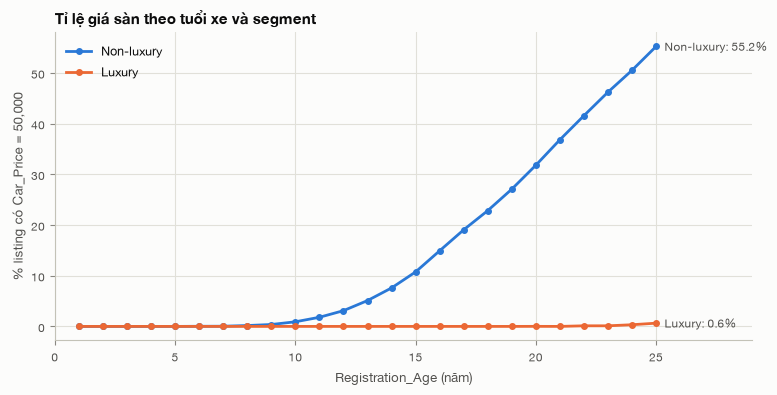

In [41]:
floor_age = df_eda.groupby(["Registration_Age", "Segment"])["floor_price"].mean().unstack() * 100
print("% giá sàn theo segment:", (df_eda.groupby("Segment")["floor_price"].mean() * 100).round(3).to_dict())
print("% giá sàn theo quintile Kms_Driven:",
      (df_eda.groupby(pd.qcut(df_raw["Kms_Driven"], 5, labels=[f"Q{i}" for i in range(1, 6)]), observed=True)["floor_price"]
       .mean() * 100).round(2).to_dict())

fig, ax = plt.subplots(figsize=(9, 4))
for seg in ["Non-luxury", "Luxury"]:
    ax.plot(floor_age.index, floor_age[seg], color=SEG_COLORS[seg], marker="o", markersize=4, label=seg)
    ax.annotate(f"{seg}: {floor_age[seg].iloc[-1]:.1f}%", (floor_age.index[-1], floor_age[seg].iloc[-1]),
                xytext=(6, 0), textcoords="offset points", va="center", fontsize=8.5, color=INK2)
ax.set_xlim(0, 29)
ax.set_xlabel("Registration_Age (năm)")
ax.set_ylabel(f"% listing có Car_Price = {PRICE_FLOOR:,.0f}")
ax.set_title("Tỉ lệ giá sàn theo tuổi xe và segment")
ax.legend(loc="upper left")
plt.show()

> 💬 **Nhận xét:** Giá sàn **gần như chỉ có ở Non-luxury** (15.04%, so với Luxury 0.05%). Tỉ lệ tăng theo tuổi xe, tới 55.2% ở xe Non-luxury 25 tuổi, và tăng theo Kms (quintile thấp nhất 0.01%, quintile cao nhất 36.28%). Vì vậy **không nên xóa** các dòng này, vì xóa sẽ loại có chọn lọc xe cũ Non-luxury.

### 5.3 Tỉ lệ outlier của price: Luxury vs Non-luxury

So sánh hai cách: dùng fence 1.5×IQR tính trên **toàn mẫu**, và dùng fence tính **riêng trong từng segment**.

In [42]:
p = df_raw["Car_Price"]
q1, q3 = p.quantile([.25, .75])
fence_all = q3 + 1.5 * (q3 - q1)
rows = []
for seg, g in df_eda.groupby("Segment"):
    s = g["Car_Price"]
    s1, s3 = s.quantile([.25, .75])
    fence_seg = s3 + 1.5 * (s3 - s1)
    rows.append({"Segment": seg, "n": len(s), "% > fence toàn mẫu": (s > fence_all).mean() * 100,
                 "tỉ trọng trong tổng outlier": (s > fence_all).sum() / (p > fence_all).sum() * 100,
                 "fence trong segment": fence_seg, "% > fence trong segment": (s > fence_seg).mean() * 100})
print(f"Fence 1.5×IQR toàn mẫu = {fence_all:,.0f}")
pd.DataFrame(rows).set_index("Segment")

Fence 1.5×IQR toàn mẫu = 2,718,663


,n,% > fence toàn mẫu,tỉ trọng trong tổng outlier,fence trong segment,% > fence trong segment
Segment,,,,,
Luxury,232172,28.528,94.064,"4,785,489.363",0.914
Non-luxury,772828,0.541,5.936,"1,965,598.124",0.662


> 💬 **Nhận xét:** Nếu dùng fence của toàn mẫu (2,718,663) thì 28.5% xe Luxury bị gắn cờ, và **94.1% số outlier giá là xe Luxury**. Dùng fence riêng trong từng segment thì chỉ còn 0.91% (Luxury) và 0.66% (Non-luxury). Do đó outlier của giá phải được đánh giá trong từng segment.

## 6. Quan hệ giữa các biến

### 6.1 Correlation matrix (Pearson & Spearman)

Tính correlation giữa 13 biến numeric trên toàn bộ dữ liệu thô (pairwise, bỏ NaN) và vẽ heatmap. Chỉ hiện nửa dưới của ma trận để đỡ rối.

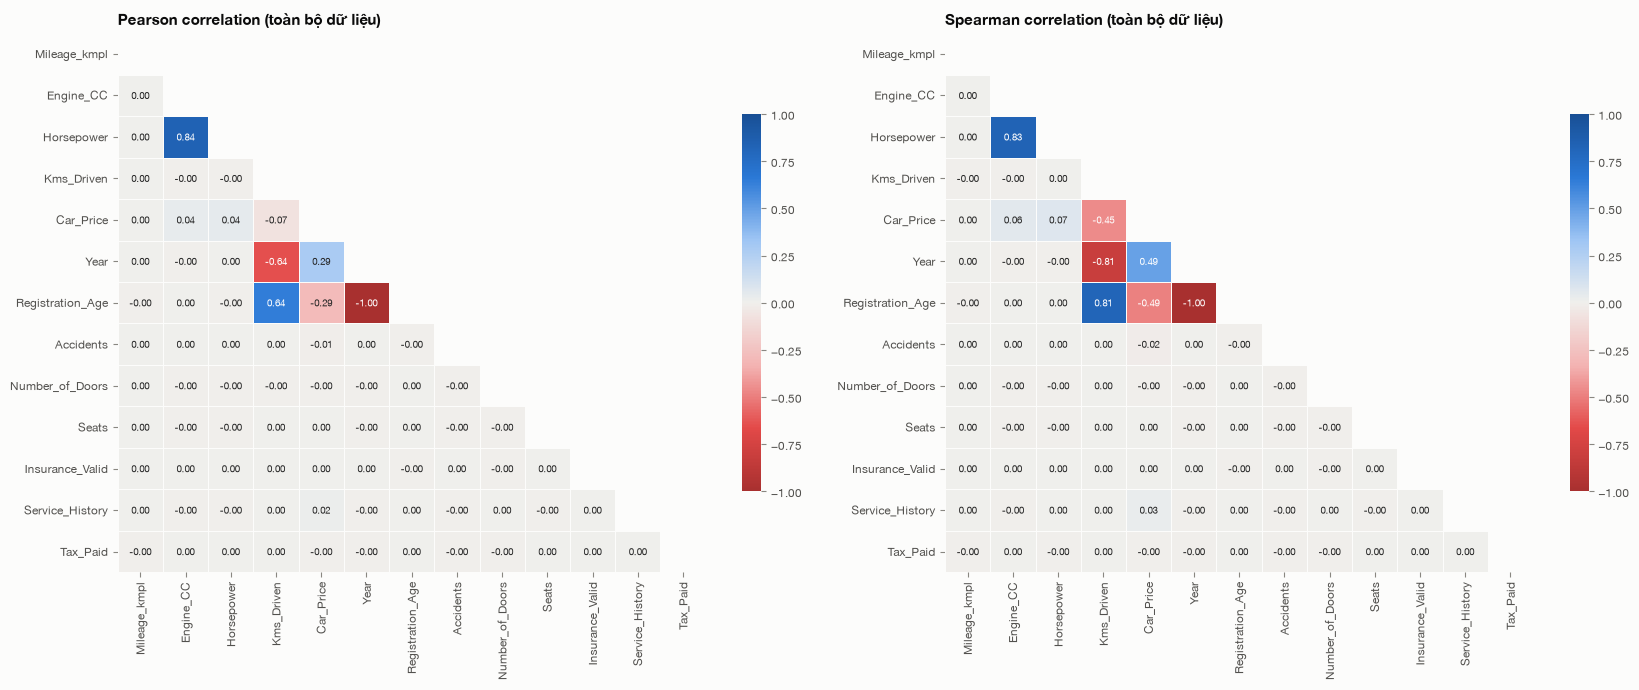

In [43]:
pear = df_raw[NUM_COLS].corr(method="pearson")
spear = df_raw[NUM_COLS].corr(method="spearman")
mask = np.triu(np.ones_like(pear, dtype=bool))
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
for ax, (name, m) in zip(axes, [("Pearson", pear), ("Spearman", spear)]):
    sns.heatmap(m, mask=mask, cmap=DIV_CMAP, vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={"size": 7},
                linewidths=0.5, linecolor=SURFACE, cbar_kws={"shrink": 0.7}, ax=ax)
    ax.set_title(f"{name} correlation (toàn bộ dữ liệu)")
    ax.grid(False)
fig.tight_layout()
plt.show()

> 💬 **Nhận xét:** Year và Registration_Age có r = **−1.00** (cùng một thông tin). Engine_CC–Horsepower 0.84; Registration_Age–Kms 0.64 (Spearman 0.81). Car_Price chỉ có quan hệ đáng kể với tuổi xe (Pearson −0.29 / Spearman −0.49) và Kms (−0.07 / −0.45). Các ô còn lại gần 0.

Correlation của `Car_Price` với từng biến: so sánh khi tính trên toàn bộ dữ liệu và khi đã bỏ duplicates + implausible (độ nhạy).

In [44]:
keep = ~df_eda["dup_extra"] & ~df_eda["imp_any"]
X = [c for c in NUM_COLS if c != TARGET]
price_corr = pd.DataFrame({
    "pearson (all)": df_raw[X].corrwith(df_raw[TARGET]),
    "pearson (bỏ dup+implausible)": df_raw.loc[keep, X].corrwith(df_raw.loc[keep, TARGET]),
    "spearman (all)": df_raw[X].corrwith(df_raw[TARGET], method="spearman"),
    "spearman (bỏ dup+implausible)": df_raw.loc[keep, X].corrwith(df_raw.loc[keep, TARGET], method="spearman"),
}).sort_values("spearman (all)", key=abs, ascending=False)
print(f"n (all) = {len(df_raw):,} | n (bỏ dup+implausible) = {keep.sum():,}")
price_corr

n (all) = 1,005,000 | n (bỏ dup+implausible) = 990,395


,pearson (all),pearson (bỏ dup+implausible),spearman (all),spearman (bỏ dup+implausible)
Year,0.287,0.357,0.490,0.493
Registration_Age,-0.287,-0.357,-0.490,-0.493
Kms_Driven,-0.074,-0.335,-0.454,-0.478
Horsepower,0.045,0.055,0.072,0.072
Engine_CC,0.037,0.046,0.060,0.061
Service_History,0.017,0.020,0.028,0.028
Accidents,-0.010,-0.013,-0.016,-0.016
Number_of_Doors,-0.002,-0.001,-0.002,-0.001
Mileage_kmpl,0.000,-0.000,0.001,0.001
Tax_Paid,-0.002,-0.001,-0.001,-0.001


> 💬 **Nhận xét:** Pearson(price, Kms) là **−0.074 trên toàn bộ** dữ liệu, nhưng thành **−0.335** sau khi bỏ dup + implausible. Nhóm 0.96% dòng lỗi đủ để che gần hết quan hệ tuyến tính này. Spearman ổn định hơn (−0.454 → −0.478). Ngoài tuổi xe và Kms, mọi biến khác có |r| ≤ 0.07.

### 6.2 Các cặp biến giải thích tương quan mạnh (nguy cơ multicollinearity)

Liệt kê các cặp biến giải thích có |r| ≥ 0.3 (theo Pearson hoặc Spearman).

In [45]:
pairs = []
for i, a in enumerate(X):
    for b in X[i + 1:]:
        rp, rs = pear.loc[a, b], spear.loc[a, b]
        pairs.append({"var_1": a, "var_2": b, "pearson": rp, "spearman": rs, "max|r|": max(abs(rp), abs(rs))})
pairs = pd.DataFrame(pairs).sort_values("max|r|", ascending=False)
print(f"Số cặp |r| >= 0.3: {(pairs['max|r|'] >= 0.3).sum()} / {len(pairs)}; "
      f"|r| lớn nhất trong các cặp còn lại = {pairs.loc[pairs['max|r|'] < 0.3, 'max|r|'].max():.4f}")
pairs[pairs["max|r|"] >= 0.3].assign(
    mức=lambda t: np.where(t["max|r|"] >= 0.7, "CAO (>= 0.7)", "trung bình")).reset_index(drop=True)

Số cặp |r| >= 0.3: 4 / 66; |r| lớn nhất trong các cặp còn lại = 0.0031


,var_1,var_2,pearson,spearman,max|r|,mức
0,Year,Registration_Age,-1.000,-1.000,1.000,CAO (>= 0.7)
1,Engine_CC,Horsepower,0.839,0.833,0.839,CAO (>= 0.7)
2,Kms_Driven,Registration_Age,0.642,0.813,0.813,CAO (>= 0.7)
3,Kms_Driven,Year,-0.642,-0.813,0.813,CAO (>= 0.7)


> 💬 **Nhận xét:** Có 4 trên 66 cặp có |r| ≥ 0.3, và cả 4 đều ≥ 0.7: Year–Age, Engine–HP, Kms–Age, Kms–Year. 62 cặp còn lại có |r| ≤ 0.0031, gần như độc lập. Ở M2 chỉ nên giữ 1 trong Year/Age và 1 trong Engine/HP.

### 6.3 Scatter: price vs các biến numeric chính

Vẽ 1 triệu điểm vừa nặng vừa khó đọc, nên scatter dùng **sample ngẫu nhiên n = 5,000 dòng** (`random_state=SEED`), tô màu theo segment, trục y là log. Correlation ghi trên tiêu đề mỗi hình vẫn tính trên **toàn bộ** dữ liệu.

Sample n = 5,000 (seed 5000): Luxury 22.0%, implausible 55 dòng, giá sàn 552 dòng


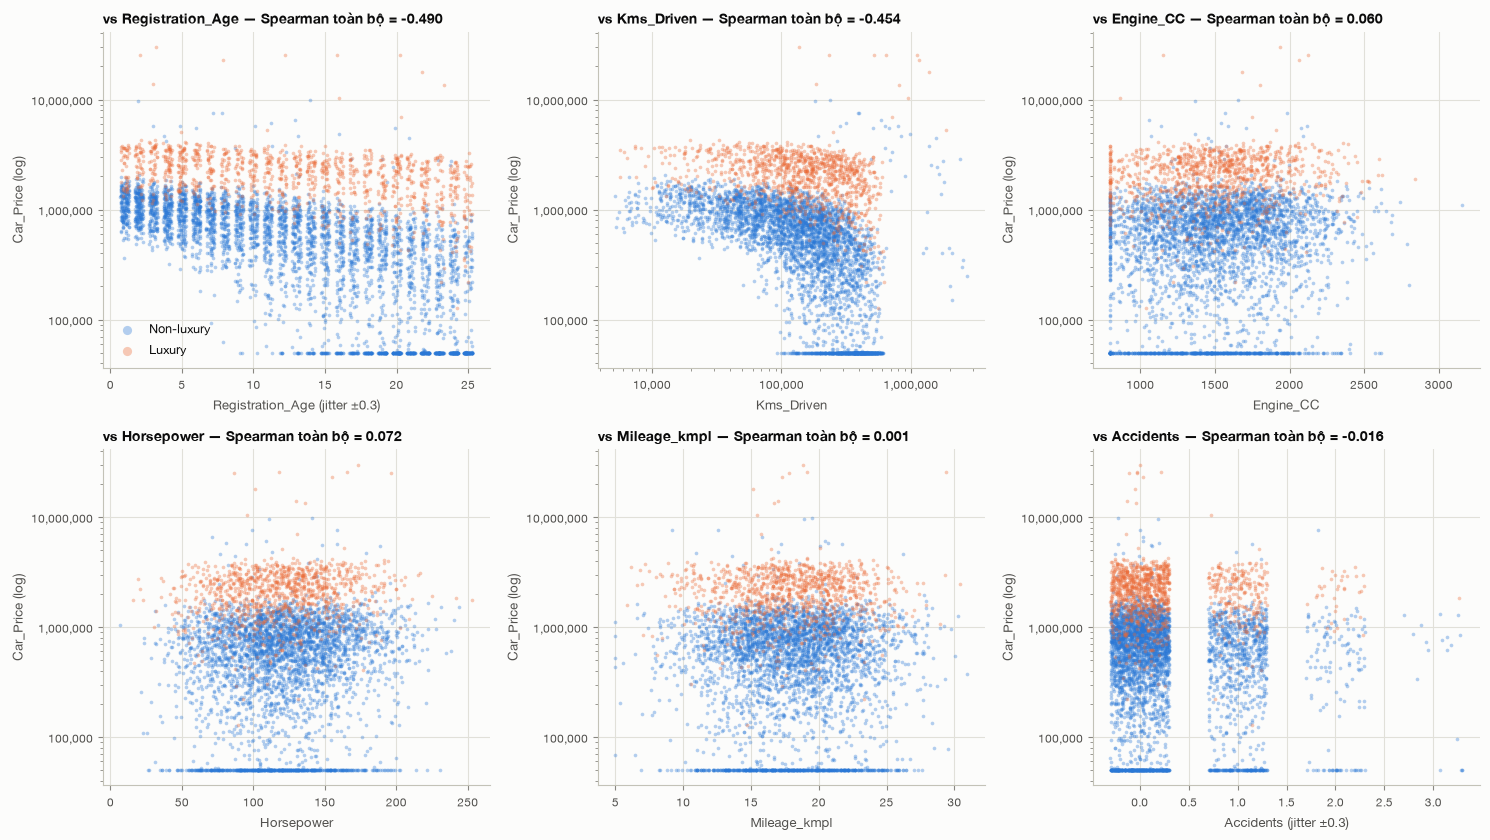

In [46]:
N_SAMPLE = 5_000
smp = df_eda.sample(n=N_SAMPLE, random_state=SEED)
print(f"Sample n = {N_SAMPLE:,} (seed {SEED}): Luxury {(smp.Segment == 'Luxury').mean() * 100:.1f}%, "
      f"implausible {int(smp.imp_any.sum())} dòng, giá sàn {int(smp.floor_price.sum())} dòng")
jit = np.random.default_rng(SEED)
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
for ax, c in zip(axes.flat, ["Registration_Age", "Kms_Driven", "Engine_CC", "Horsepower", "Mileage_kmpl", "Accidents"]):
    for seg in ["Non-luxury", "Luxury"]:
        g = smp[smp.Segment == seg]
        x = g[c] + (jit.uniform(-0.3, 0.3, len(g)) if c in ("Registration_Age", "Accidents") else 0)
        ax.scatter(x, g["Car_Price"], s=7, alpha=0.35, color=SEG_COLORS[seg], linewidths=0, label=seg)
    ax.set_yscale("log")
    thousands(ax)
    if c == "Kms_Driven":
        ax.set_xscale("log")
        thousands(ax, "x")
    ax.set_xlabel(c + (" (jitter ±0.3)" if c in ("Registration_Age", "Accidents") else ""))
    ax.set_ylabel("Car_Price (log)")
    ax.set_title(f"vs {c} — Spearman toàn bộ = {df_raw['Car_Price'].corr(df_raw[c], method='spearman'):.3f}", fontsize=10)
axes[0, 0].legend(loc="lower left", markerscale=2.5)
fig.tight_layout()
plt.show()

> 💬 **Nhận xét:** Sample n = 5,000 (seed 5000) có 22.0% Luxury, 55 dòng implausible và 552 dòng giá sàn. Biểu đồ cho thấy hai dải giá tách biệt theo segment, dải giá sàn nằm ngang ở 50,000, và giá giảm theo tuổi xe và Kms. Engine, HP, Mileage và Accidents không tạo xu hướng rõ.

### 6.4 Crosstab giữa các biến categorical quan trọng

Tính crosstab theo row %: với mỗi segment, cơ cấu Fuel, Transmission và Owner ra sao?

In [47]:
for a, b in [("Segment", "Fuel_std"), ("Segment", "Transmission"), ("Segment", "Owner_Type")]:
    display((pd.crosstab(df_eda[a], df_eda[b], normalize="index") * 100).round(2))

Fuel_std,CNG,Diesel,Electric,Hybrid,Petrol,Unknown
Segment,,,,,,
Luxury,9.040,27.790,7.480,6.680,41.160,7.840
Non-luxury,9.010,27.730,7.560,6.640,41.230,7.830


Transmission,Automatic,Manual,Unknown
Segment,,,
Luxury,32.230,59.680,8.090
Non-luxury,32.240,59.790,7.970


Owner_Type,First,Fourth+,Second,Third
Segment,,,,
Luxury,59.900,5.070,25.020,10.010
Non-luxury,59.950,4.980,25.050,10.020


> 💬 **Nhận xét:** Cơ cấu Fuel, Transmission và Owner **gần như giống hệt nhau** giữa hai segment, ví dụ Petrol 41.16% so với 41.23%, Manual 59.68% so với 59.79%.

Tóm tắt thêm nhiều cặp khác bằng một chỉ số: chênh lệch lớn nhất (tính bằng điểm %) giữa các hàng trong cùng một cột của crosstab row %.

In [48]:
ct_pairs = [("Segment", "Fuel_std"), ("Segment", "Transmission"), ("Segment", "Owner_Type"), ("Segment", "City"),
            ("Segment", "Color"), ("Fuel_std", "Transmission"), ("City", "Fuel_std"), ("Brand_std", "Fuel_std"),
            ("Owner_Type", "Transmission")]
pd.DataFrame([{"row": a, "col": b,
               "chênh lệch max (điểm %)": (lambda ct: (ct.max() - ct.min()).max())(
                   pd.crosstab(df_eda[a], df_eda[b], normalize="index") * 100)} for a, b in ct_pairs])

,row,col,chênh lệch max (điểm %)
0,Segment,Fuel_std,0.081
1,Segment,Transmission,0.120
2,Segment,Owner_Type,0.093
3,Segment,City,0.090
4,Segment,Color,0.130
5,Fuel_std,Transmission,0.383
6,City,Fuel_std,0.335
7,Brand_std,Fuel_std,1.041
8,Owner_Type,Transmission,0.121


> 💬 **Nhận xét:** Chênh lệch lớn nhất giữa các hàng là ≤ 0.38 điểm %, riêng Brand × Fuel là 1.04 điểm %. Như vậy các biến categorical **độc lập với nhau** và với segment, nên không có confounding giữa chúng.

## 7. Phân tích biến mục tiêu (Car_Price)

### 7.1 Phân phối của price gốc và log1p(price)

Vẽ histogram của hai thang đo và so sánh skewness/kurtosis, trên toàn bộ dữ liệu và khi đã bỏ duplicates + implausible.

,all,bỏ dup+implausible
skew(price),6.991,2.056
kurt(price),116.466,21.125
skew(log1p price),-0.730,-0.785
kurt(log1p price),-0.154,-0.210
mean/median(price),1.335,1.283


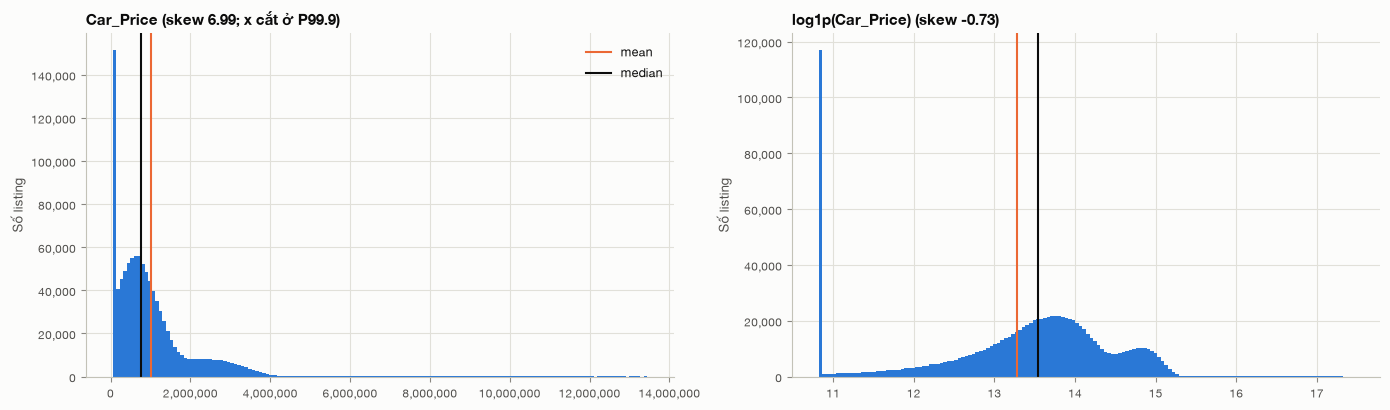

In [49]:
lp = np.log1p(df_raw["Car_Price"])
skew_tab = pd.DataFrame({
    "all": [df_raw.Car_Price.skew(), df_raw.Car_Price.kurt(), lp.skew(), lp.kurt(),
            df_raw.Car_Price.mean() / df_raw.Car_Price.median()],
    "bỏ dup+implausible": [df_raw.Car_Price[keep].skew(), df_raw.Car_Price[keep].kurt(), lp[keep].skew(), lp[keep].kurt(),
                           df_raw.Car_Price[keep].mean() / df_raw.Car_Price[keep].median()],
}, index=["skew(price)", "kurt(price)", "skew(log1p price)", "kurt(log1p price)", "mean/median(price)"])
display(skew_tab)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
hi = df_raw.Car_Price.quantile(0.999)
axes[0].hist(df_raw.Car_Price[df_raw.Car_Price <= hi], bins=150, color=C1, linewidth=0)
axes[0].set_title(f"Car_Price (skew {df_raw.Car_Price.skew():.2f}; x cắt ở P99.9)")
thousands(axes[0]); thousands(axes[0], "x")
axes[1].hist(lp, bins=150, color=C1, linewidth=0)
axes[1].set_title(f"log1p(Car_Price) (skew {lp.skew():.2f})")
thousands(axes[1])
for ax, s in [(axes[0], df_raw.Car_Price), (axes[1], lp)]:
    ax.axvline(s.mean(), color=C2, linewidth=1.5, label="mean")
    ax.axvline(s.median(), color=INK, linewidth=1.5, label="median")
    ax.set_ylabel("Số listing")
axes[0].legend()
fig.tight_layout()
plt.show()

> 💬 **Nhận xét:** Skew của price giảm từ **6.99 xuống −0.73** khi dùng log1p. Chỉ riêng việc bỏ dup + implausible đã giảm skew từ 6.99 xuống 2.06. Log1p làm phân phối lệch trái nhẹ, vì cột giá sàn ở log1p(50,000) ≈ 10.8 và vì giá có 2 bướu theo segment. Mean/median = 1.34, cho thấy lệch phải, nên **median** mới là con số nên báo cáo cho khách hàng.

### 7.2 Price theo từng biến categorical

Chạy `groupby(cat)['Car_Price'].agg(['count','mean','median','std'])` cho từng biến categorical và rời rạc. Bảng thứ nhất tóm tắt mức chênh lệch median giữa các nhóm của mỗi biến; sau đó là bảng đầy đủ cho các biến có khác biệt rõ.

In [50]:
def price_by(df, col):
    return df.groupby(col)["Car_Price"].agg(["count", "mean", "median", "std"])


GROUP_VARS = ["Segment", "Brand_std", "Model", "Fuel_std", "Transmission", "Owner_Type", "Color", "City",
              "Accidents", "Service_History", "Insurance_Valid", "Tax_Paid", "Seats", "Number_of_Doors"]
by = {c: price_by(df_eda, c) for c in GROUP_VARS}
summary = pd.DataFrame({c: {"n_groups": len(t), "nhóm có median thấp nhất": str(t["median"].idxmin()),
                            "median thấp nhất": t["median"].min(), "nhóm có median cao nhất": str(t["median"].idxmax()),
                            "median cao nhất": t["median"].max(), "max/min": t["median"].max() / t["median"].min()}
                        for c, t in by.items()}).T
summary = summary.astype({"n_groups": int, "median thấp nhất": float, "median cao nhất": float, "max/min": float})
summary.sort_values("max/min", ascending=False)

,n_groups,nhóm có median thấp nhất,median thấp nhất,nhóm có median cao nhất,median cao nhất,max/min
Model,39,Harrier,"447,508.944",E-Class,"2,420,651.751",5.409
Brand_std,13,Tata,"450,583.038",Mercedes,"2,402,907.535",5.333
Segment,2,Non-luxury,"581,504.665",Luxury,"2,155,953.235",3.708
Accidents,6,5,"392,982.682",0,"765,227.476",1.947
Service_History,2,0,"723,252.505",1,"770,614.217",1.065
Fuel_std,6,CNG,"755,053.594",Hybrid,"762,929.994",1.010
Color,8,Silver,"754,588.205",Brown,"761,306.574",1.009
City,9,Pune,"755,895.745",Delhi,"761,668.301",1.008
Number_of_Doors,3,5,"758,437.815",2,"764,138.837",1.008
Transmission,3,Automatic,"758,096.590",Unknown,"760,339.853",1.003


> 💬 **Nhận xét:** Median giá khác biệt lớn theo **Model (5.41×)**, **Brand (5.33×)** và **Segment (3.71×)**. Accidents cũng có tỉ số 1.95×, nhưng chủ yếu do nhóm 5 tai nạn chỉ có 16 dòng. Service_History 1.07×. **Mọi biến còn lại ≤ 1.01×**, tức không tạo khác biệt về giá.

Bảng đầy đủ cho Segment, Brand, Accidents và Service_History, là các biến có median khác biệt rõ giữa các nhóm.

In [51]:
for c in ["Segment", "Brand_std", "Accidents", "Service_History"]:
    display(by[c].sort_values("median", ascending=False) if c == "Brand_std" else by[c])

,count,mean,median,std
Segment,,,,
Luxury,232172,"2,263,044.807","2,155,953.235","1,551,251.329"
Non-luxury,772828,"637,329.142","581,504.665","601,180.880"


,count,mean,median,std
Brand_std,,,,
Mercedes,77305,"2,515,450.915","2,402,907.535","1,721,721.271"
BMW,77561,"2,191,307.600","2,099,703.186","1,462,679.590"
Audi,77306,"2,082,615.803","1,996,373.792","1,419,474.981"
Volkswagen,77185,"792,197.699","745,318.534","677,575.848"
Skoda,77551,"745,236.698","700,742.901","652,619.380"
Kia,77293,"744,362.571","697,309.661","666,961.252"
Honda,77312,"650,912.508","601,088.199","601,498.236"
Toyota,77397,"647,854.522","598,276.741","596,135.694"
Hyundai,77517,"605,701.197","554,232.809","579,477.184"


,count,mean,median,std
Accidents,,,,
0,744978,"1,018,995.063","765,227.476","1,145,806.170"
1,222955,"999,199.187","744,019.233","1,130,025.212"
2,33434,"979,340.020","722,735.074","1,137,879.187"
3,3395,"912,426.717","676,006.319","1,010,409.025"
4,222,"922,580.904","709,434.638","941,997.023"
5,16,"645,636.113","392,982.682","898,486.618"


,count,mean,median,std
Service_History,,,,
0,250486,"978,951.644","723,252.505","1,121,166.484"
1,754514,"1,024,166.236","770,614.217","1,148,141.560"


> 💬 **Nhận xét:** Median của Luxury là 2.00–2.40M (Mercedes cao nhất), của Non-luxury là 0.45–0.75M (Tata thấp nhất, Volkswagen cao nhất). Median giảm dần theo số tai nạn (0 vụ: 765k; 3 vụ: 676k). Xe có Service_History cao hơn 6.5% (770,614 so với 723,253).

Vẽ boxplot của price theo nhóm (thang log, không vẽ fliers). Hàm `plot_box_by` dùng chung cho mọi biến.

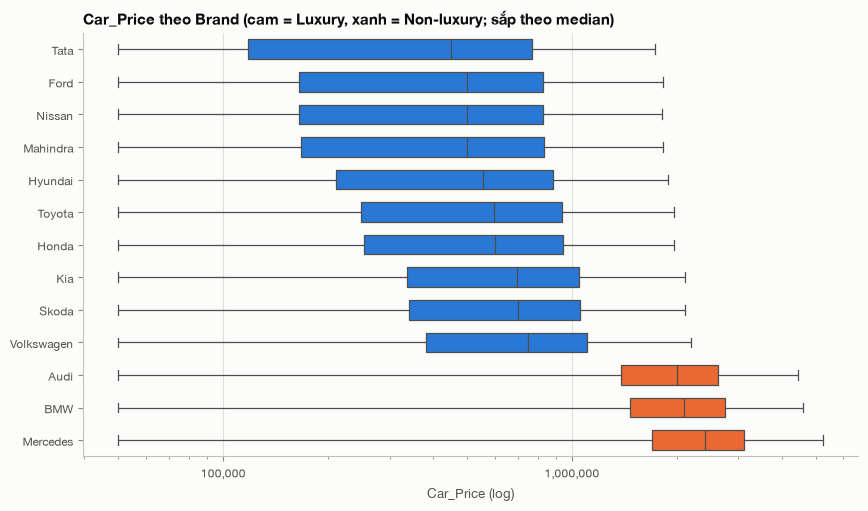

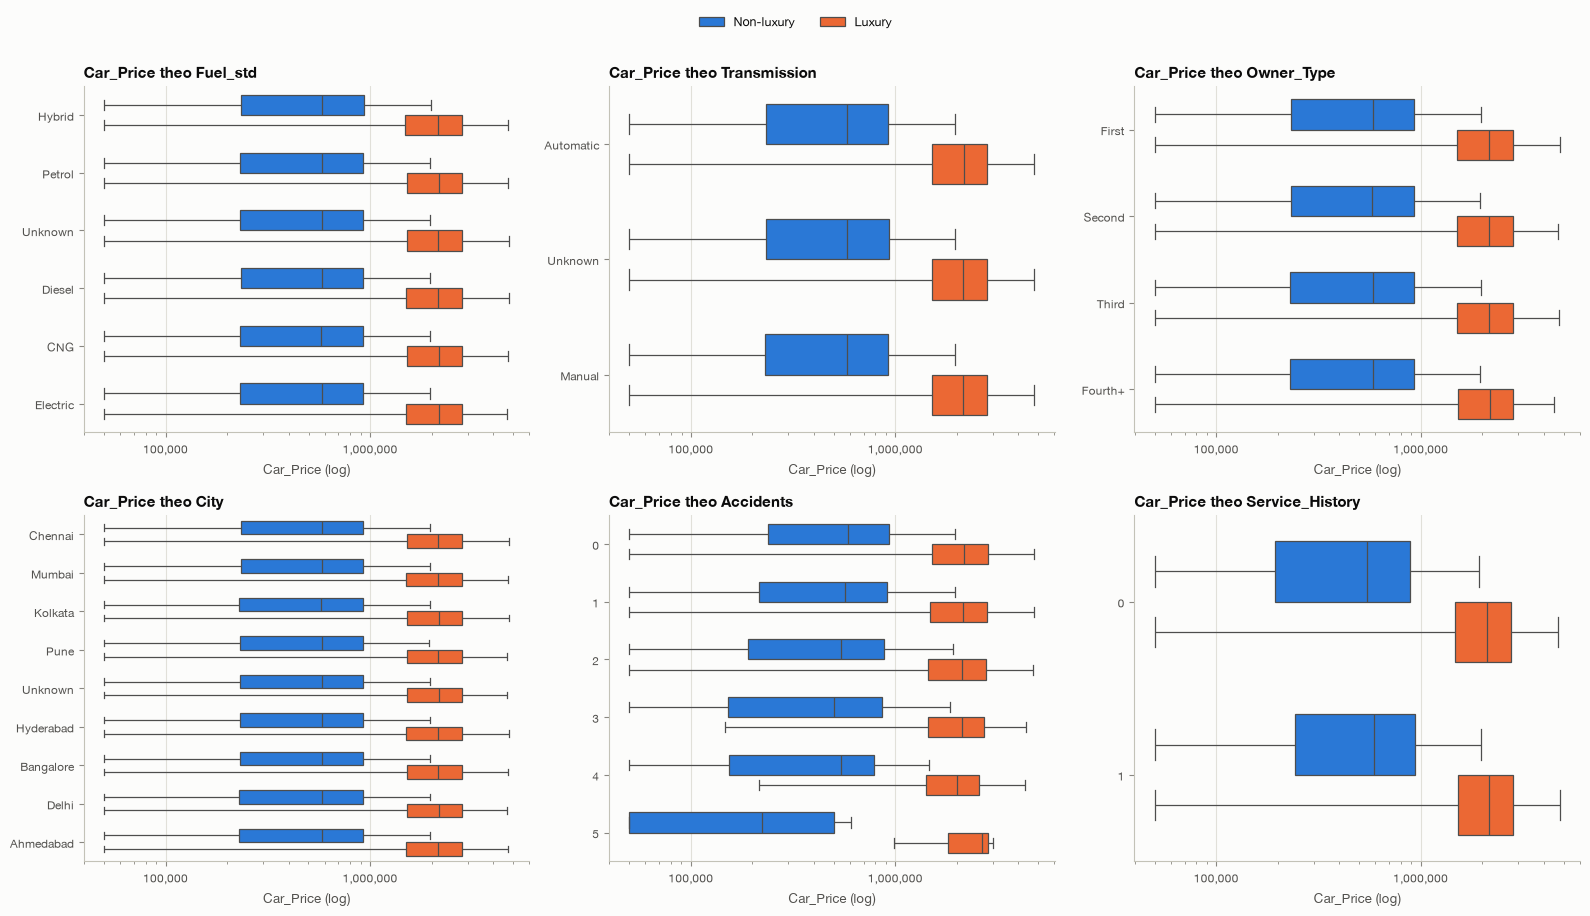

In [52]:
def plot_box_by(df, col, ax, hue="Segment", order=None):
    sns.boxplot(data=df, x="Car_Price", y=col, hue=hue, order=order, ax=ax, showfliers=False, width=0.7, orient="h",
                palette=SEG_COLORS if hue else None, linewidth=0.9, saturation=1,
                hue_order=["Non-luxury", "Luxury"] if hue else None)
    ax.set_xscale("log")
    thousands(ax, "x")
    ax.set_xlabel("Car_Price (log)")
    ax.set_ylabel("")
    ax.set_title(f"Car_Price theo {col}")
    ax.grid(axis="y", visible=False)


fig, ax = plt.subplots(figsize=(10, 5.5))
order = by["Brand_std"]["median"].sort_values().index.tolist()
sns.boxplot(data=df_eda, x="Car_Price", y="Brand_std", hue="Brand_std", legend=False, order=order, ax=ax,
            showfliers=False, width=0.6, orient="h", linewidth=0.9, saturation=1,
            palette={b: SEG_COLORS["Luxury" if b in LUXURY else "Non-luxury"] for b in order})
ax.set_xscale("log"); thousands(ax, "x"); ax.set_xlabel("Car_Price (log)"); ax.set_ylabel(""); ax.grid(axis="y", visible=False)
ax.set_title("Car_Price theo Brand (cam = Luxury, xanh = Non-luxury; sắp theo median)")
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, c in zip(axes.flat, ["Fuel_std", "Transmission", "Owner_Type", "City", "Accidents", "Service_History"]):
    plot_box_by(df_eda, c, ax, order=["First", "Second", "Third", "Fourth+"] if c == "Owner_Type" else None)
    ax.get_legend().remove()
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncols=2, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

> 💬 **Nhận xét:** Hộp của 3 brand Luxury tách hẳn khỏi 10 brand Non-luxury. Trong mỗi segment, hộp theo Fuel, Transmission, Owner và City **gần như trùng nhau**. Chỉ Accidents (hộp dịch trái dần khi số vụ tăng) và Service_History = 0 (hơi thấp hơn) cho thấy khác biệt.

### 7.3 Luxury vs Non-luxury

Cột `Segment` là **cột tạm** đã tạo ở 3.4 theo mapping: `Brand.str.strip()`, sau đó Audi, BMW, Mercedes → Luxury, còn lại → Non-luxury. Nhờ bước TRIM, 2,334 dòng `' Audi '`, `' BMW '`, `' Mercedes '` được xếp đúng vào Luxury.

So sánh phân phối price giữa hai segment: trên toàn bộ dữ liệu, và khi đã bỏ duplicates + implausible.

count          mean           std        min           10%           25%           50%           75%           90%            max    CV  % giá sàn
                   Segment                                                                                                                                                            
all                Luxury     232,172.000 2,263,044.807 1,551,251.329 50,000.000 1,034,681.501 1,506,585.130 2,155,953.235 2,818,146.823 3,334,728.492 37,885,997.533 0.685      0.049
                   Non-luxury 772,828.000   637,329.142   601,180.880 50,000.000    50,000.000   231,352.006   581,504.665   925,050.453 1,226,126.616 16,183,316.062 0.943     15.044
bỏ dup+implausible Luxury     228,820.000 2,158,606.608   903,697.808 50,000.000 1,031,075.334 1,499,809.365 2,143,643.629 2,798,125.076 3,297,677.738 34,305,029.612 0.419      0.050
                   Non-luxury 761,575.000   608,744.054   440,220.274 50,000.000    50,000.000   228,109.152   577,740.680   916,992.194 1,209,766.066 15,240,343.885 0.723     15.191

[all] Luxury/Non-luxury: median ×3.71, mean ×3.55; chênh median = 1,574,449 Rs
[bỏ dup+implausible] Luxury/Non-luxury: median ×3.71, mean ×3.55; chênh median = 1,565,903 Rs


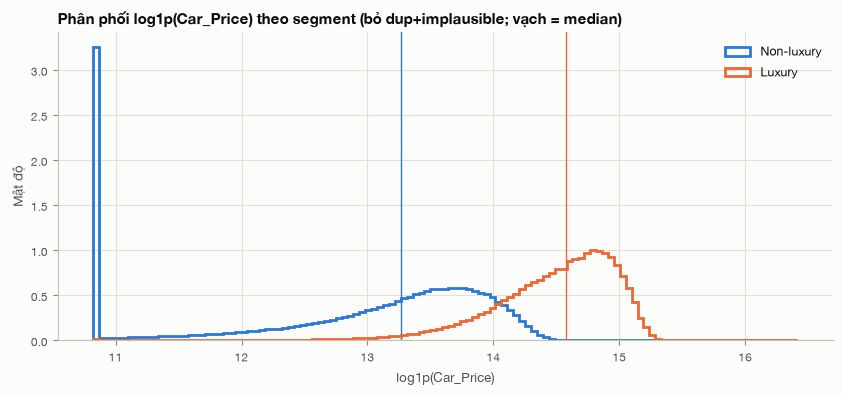

In [53]:
def seg_stats(df):
    g = df.groupby("Segment")["Car_Price"]
    t = g.describe(percentiles=[.1, .25, .5, .75, .9])
    t["CV"] = t["std"] / t["mean"]
    t["% giá sàn"] = df.groupby("Segment")["floor_price"].mean() * 100
    return t


seg_all, seg_keep = seg_stats(df_eda), seg_stats(df_eda[keep])
display(pd.concat({"all": seg_all, "bỏ dup+implausible": seg_keep}))
for name, t in [("all", seg_all), ("bỏ dup+implausible", seg_keep)]:
    print(f"[{name}] Luxury/Non-luxury: median ×{t.loc['Luxury', '50%'] / t.loc['Non-luxury', '50%']:.2f}, "
          f"mean ×{t.loc['Luxury', 'mean'] / t.loc['Non-luxury', 'mean']:.2f}; "
          f"chênh median = {t.loc['Luxury', '50%'] - t.loc['Non-luxury', '50%']:,.0f} Rs")

fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(np.log1p(PRICE_FLOOR), np.log1p(df_raw.Car_Price.quantile(0.999)), 120)
for seg in ["Non-luxury", "Luxury"]:
    s = np.log1p(df_eda.loc[keep & (df_eda.Segment == seg), "Car_Price"])
    ax.hist(s, bins=bins, density=True, histtype="step", linewidth=2, color=SEG_COLORS[seg], label=seg)
    ax.axvline(s.median(), color=SEG_COLORS[seg], linewidth=1)
ax.set_xlabel("log1p(Car_Price)"); ax.set_ylabel("Mật độ")
ax.set_title("Phân phối log1p(Car_Price) theo segment (bỏ dup+implausible; vạch = median)")
ax.legend()
plt.show()

> 💬 **Nhận xét:** Median Luxury gấp **3.71 lần** Non-luxury ở cả hai view (chênh khoảng 1.57M Rs); mean gấp 3.55 lần. Non-luxury biến động tương đối lớn hơn (CV 0.72 so với 0.42), và P10 của Non-luxury chạm giá sàn 50,000 (15.2% số xe ở giá sàn). Hai phân phối log-price chồng lấn ít.

Tính correlation của price với từng biến numeric **riêng trong từng segment** (đã bỏ dup + implausible), để xem quan hệ có khác nhau giữa hai segment không.

In [54]:
Xs = ["Registration_Age", "Kms_Driven", "Engine_CC", "Horsepower", "Mileage_kmpl", "Accidents", "Service_History"]
seg_corr = {}
for seg in ["Luxury", "Non-luxury"]:
    d = df_eda[keep & (df_eda.Segment == seg)]
    seg_corr[(seg, "pearson")] = d[Xs].corrwith(d["Car_Price"])
    seg_corr[(seg, "spearman")] = d[Xs].corrwith(d["Car_Price"], method="spearman")
seg_corr = pd.DataFrame(seg_corr)
seg_corr[("chênh", "spearman Non − Lux")] = seg_corr[("Non-luxury", "spearman")] - seg_corr[("Luxury", "spearman")]
seg_corr

Luxury          Non-luxury                       chênh
                 pearson spearman    pearson spearman spearman Non − Lux
Registration_Age  -0.383   -0.385     -0.689   -0.713             -0.328
Kms_Driven        -0.368   -0.375     -0.638   -0.690             -0.316
Engine_CC          0.052    0.050      0.088    0.087              0.037
Horsepower         0.062    0.060      0.105    0.104              0.044
Mileage_kmpl      -0.001   -0.002      0.003    0.004              0.006
Accidents         -0.018   -0.016     -0.025   -0.024             -0.008
Service_History    0.023    0.023      0.041    0.041              0.018

> 💬 **Nhận xét:** Quan hệ giữa giá và tuổi xe **mạnh hơn nhiều ở Non-luxury** (Spearman −0.713) so với Luxury (−0.385); với Kms cũng vậy (−0.690 so với −0.375). Các biến khác gần 0 ở cả hai segment. Đây là gợi ý cho interaction Segment × Age và Segment × Kms ở M2.

Tính độ dốc trendline, tức đường least squares **thuần mô tả** giống trendline trong Excel, chưa phải mô hình suy luận. Độ dốc được tính theo **Rupees** và theo **%** (thông qua log1p(price)), cho từng segment.

In [55]:
rows = []
for seg in ["Luxury", "Non-luxury"]:
    for label, m in [("bỏ dup+implausible", keep), ("…và bỏ giá sàn", keep & ~df_eda.floor_price)]:
        d = df_eda[m & (df_eda.Segment == seg)]
        for x, unit in [("Registration_Age", 1), ("Kms_Driven", 10_000), ("Accidents", 1)]:
            b_rs = np.polyfit(d[x], d["Car_Price"], 1)[0] * unit
            b_pct = (np.exp(np.polyfit(d[x], np.log1p(d["Car_Price"]), 1)[0] * unit) - 1) * 100
            rows.append({"Segment": seg, "view": label, "x (đơn vị)": f"{x} (+{unit:,})",
                         "Rupees / đơn vị": b_rs, "% / đơn vị": b_pct})
slopes = pd.DataFrame(rows).pivot_table(index=["x (đơn vị)", "view"], columns="Segment",
                                        values=["Rupees / đơn vị", "% / đơn vị"])
within_age = {seg: df_eda[keep & (df_eda.Segment == seg)].groupby("Registration_Age")[["Car_Price", "Kms_Driven"]]
              .apply(lambda t: t.corr("spearman").iloc[0, 1]).mean() for seg in ["Luxury", "Non-luxury"]}
print("Spearman(price, Kms) TRONG từng nhóm tuổi (trung bình 25 nhóm):", {k: round(v, 3) for k, v in within_age.items()})
slopes

Spearman(price, Kms) TRONG từng nhóm tuổi (trung bình 25 nhóm): {'Luxury': np.float64(-0.109), 'Non-luxury': np.float64(-0.234)}


% / đơn vị            Rupees / đơn vị            
Segment                                      Luxury Non-luxury          Luxury  Non-luxury
x (đơn vị)            view                                                                
Accidents (+1)        bỏ dup+implausible     -1.622     -4.794     -28,956.617 -20,467.666
                      …và bỏ giá sàn         -1.614     -2.292     -28,914.421 -14,911.037
Kms_Driven (+10,000)  bỏ dup+implausible     -1.461     -5.212     -24,058.384 -20,310.352
                      …và bỏ giá sàn         -1.432     -3.329     -23,942.481 -18,689.830
Registration_Age (+1) bỏ dup+implausible     -2.735     -9.843     -47,985.675 -42,037.004
                      …và bỏ giá sàn         -2.700     -6.064     -47,817.261 -35,707.255

> 💬 **Nhận xét:** **Theo Rupees**, mỗi năm tuổi làm giá giảm gần như bằng nhau ở hai segment: −47,986 (Luxury) và −42,037 (Non-luxury); Non-luxury thấp hơn vì giá sàn chặn phần dưới. **Theo %**, Non-luxury mất giá nhanh hơn khoảng 3.6 lần (−9.8% so với −2.7%/năm). Kms vẫn liên quan tới giá **trong cùng một tuổi** (Spearman −0.11 / −0.23), nên Kms mang thêm thông tin ngoài tuổi xe.

## 8. Phân tích theo nhóm và thời gian

Tính số listing và median price theo City, Brand và Segment (bỏ dup + implausible).

In [56]:
def group_summary(df, col):
    t = df.groupby(col).agg(n=("Car_Price", "size"), median_price=("Car_Price", "median"),
                            pct_luxury=("Segment", lambda s: (s == "Luxury").mean() * 100))
    t.insert(1, "pct", t["n"] / len(df) * 100)
    return t.join(df.groupby([col, "Segment"])["Car_Price"].median().unstack().add_prefix("median_"))


d_keep = df_eda[keep]
city_tab = group_summary(d_keep, "City")
known = city_tab.drop("Unknown")
print(f"City (trừ Unknown): median price {known.median_price.min():,.0f} – {known.median_price.max():,.0f} "
      f"(chênh {(known.median_price.max() / known.median_price.min() - 1) * 100:.2f}%)")
display(city_tab)
display(group_summary(d_keep, "Brand_std").sort_values("median_price", ascending=False)[["n", "pct", "median_price"]].T)
display(group_summary(d_keep, "Segment")[["n", "pct", "median_price"]])

City (trừ Unknown): median price 750,335 – 756,563 (chênh 0.83%)


,n,pct,median_price,pct_luxury,median_Luxury,median_Non-luxury
City,,,,,,
Ahmedabad,113814,11.492,"753,959.371",23.232,"2,135,851.828","579,136.672"
Bangalore,113747,11.485,"751,255.438",23.050,"2,146,584.220","576,604.457"
Chennai,113362,11.446,"753,481.066",23.127,"2,139,573.956","577,555.066"
Delhi,114287,11.540,"756,187.115",23.084,"2,150,875.171","578,750.881"
Hyderabad,114158,11.527,"754,123.813",23.035,"2,134,240.477","578,557.703"
Kolkata,113777,11.488,"752,153.186",23.070,"2,151,642.385","575,136.348"
Mumbai,114079,11.519,"756,563.084",23.159,"2,140,529.663","581,037.261"
Pune,113928,11.503,"750,335.042",23.042,"2,145,697.960","576,491.306"
Unknown,79243,8.001,"755,849.176",23.153,"2,150,424.966","576,450.761"


Brand_std,Mercedes,BMW,Audi,Volkswagen,Skoda,Kia,Honda,Toyota,Hyundai,Mahindra,Ford,Nissan,Tata
n,"76,182.000","76,383.000","76,255.000","76,037.000","76,434.000","76,195.000","76,197.000","76,251.000","76,419.000","75,956.000","76,364.000","75,823.000","75,899.000"
pct,7.692,7.712,7.699,7.677,7.718,7.693,7.694,7.699,7.716,7.669,7.710,7.656,7.664
median_price,"2,388,607.904","2,087,018.412","1,984,633.897","740,750.227","696,931.685","692,866.985","597,538.366","594,584.380","550,314.275","496,917.841","496,303.442","496,176.225","447,228.332"


,n,pct,median_price
Segment,,,
Luxury,228820,23.104,"2,143,643.629"
Non-luxury,761575,76.896,"577,740.680"


> 💬 **Nhận xét:** Median giá giữa các city chỉ chênh **0.83%** (750,335 – 756,563), và % Luxury ở các city là 23.03–23.23%, nên City gần như không liên quan tới giá. Theo Brand, median từ Tata 447k đến Mercedes 2.39M; 3 brand Luxury đều trên 1.98M, còn 10 brand Non-luxury đều dưới 0.75M.

Vẽ median price theo **tuổi xe** và theo **năm sản xuất**, riêng cho từng segment; thêm chỉ số median với tuổi 1 = 100.

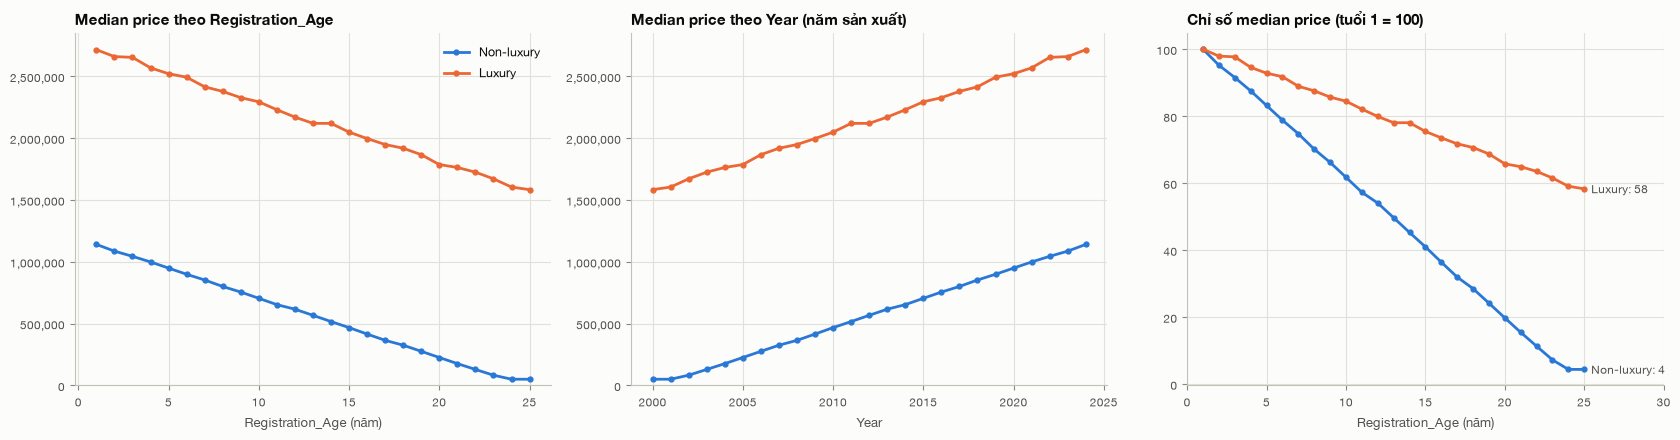

In [57]:
age_med = d_keep.groupby(["Registration_Age", "Segment"])["Car_Price"].median().unstack()
year_med = d_keep.groupby(["Year", "Segment"])["Car_Price"].median().unstack()
idx = age_med / age_med.iloc[0] * 100

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for seg in ["Non-luxury", "Luxury"]:
    axes[0].plot(age_med.index, age_med[seg], color=SEG_COLORS[seg], marker="o", markersize=3.5, label=seg)
    axes[1].plot(year_med.index, year_med[seg], color=SEG_COLORS[seg], marker="o", markersize=3.5, label=seg)
    axes[2].plot(idx.index, idx[seg], color=SEG_COLORS[seg], marker="o", markersize=3.5, label=seg)
    axes[2].annotate(f"{seg}: {idx[seg].iloc[-1]:.0f}", (idx.index[-1], idx[seg].iloc[-1]), xytext=(5, 0),
                     textcoords="offset points", va="center", fontsize=8.5, color=INK2)
axes[0].set_title("Median price theo Registration_Age"); axes[0].set_xlabel("Registration_Age (năm)")
axes[1].set_title("Median price theo Year (năm sản xuất)"); axes[1].set_xlabel("Year")
axes[2].set_title("Chỉ số median price (tuổi 1 = 100)"); axes[2].set_xlabel("Registration_Age (năm)")
axes[2].set_xlim(0, 30)
for ax in axes[:2]:
    thousands(ax); ax.set_ylim(0, None)
axes[0].legend()
fig.tight_layout()
plt.show()

> 💬 **Nhận xét:** Median giá theo tuổi của hai segment là **hai đường gần như song song** (theo Rupees). Nhưng theo chỉ số (tuổi 1 = 100), ở tuổi 25 Luxury còn **58** còn Non-luxury chỉ còn **4**. Cùng dữ liệu, nhưng kết luận về interaction phụ thuộc vào thang đo.

Fit đường thẳng mô tả trên **các median theo tuổi** (mỗi tuổi 1 điểm, dùng tuổi 1–20 để tránh vùng bị giá sàn chặn). Xem thêm Kms_Driven thay đổi thế nào theo tuổi.

In [58]:
rows = []
for seg in ["Luxury", "Non-luxury"]:
    a = age_med.loc[1:20, seg]
    x = a.index.to_numpy(dtype=float)
    b1, b0 = np.polyfit(x, a.values, 1)
    r2 = 1 - np.var(a.values - (b0 + b1 * x)) / np.var(a.values)
    b_log = np.polyfit(x, np.log(a.values), 1)[0]
    rows.append({"Segment": seg, "Rupees / năm tuổi": b1, "R²": r2, "% / năm tuổi": (np.exp(b_log) - 1) * 100,
                 "median tuổi 1": a.iloc[0], "median tuổi 20": a.iloc[-1],
                 "median tuổi 25": age_med.loc[25, seg]})
display(pd.DataFrame(rows).set_index("Segment"))
gap = age_med["Luxury"] - age_med["Non-luxury"]
print("Chênh median Luxury − Non-luxury theo tuổi:", {a: f"{gap[a]:,.0f}" for a in [1, 5, 10, 15, 20, 25]})
kms_age = d_keep.groupby("Registration_Age")["Kms_Driven"].median()
print("Median Kms_Driven / tuổi:", {a: f"{kms_age[a] / a:,.0f}" for a in [1, 5, 10, 20, 25]})

,Rupees / năm tuổi,R²,% / năm tuổi,median tuổi 1,median tuổi 20,median tuổi 25
Segment,,,,,,
Luxury,"-48,047.099",0.997,-2.120,"2,715,831.739","1,786,548.054","1,583,530.203"
Non-luxury,"-48,071.533",1.000,-7.632,"1,140,657.713","225,631.698","50,000.000"


Chênh median Luxury − Non-luxury theo tuổi: {1: '1,575,174', 5: '1,572,536', 10: '1,589,734', 15: '1,581,434', 20: '1,560,916', 25: '1,533,530'}
Median Kms_Driven / tuổi: {1: '15,112', 5: '14,996', 10: '14,977', 20: '14,966', 25: '15,068'}


> 💬 **Nhận xét:** Fit trên median ở tuổi 1–20: **−48,047 Rs/năm (Luxury) và −48,072 Rs/năm (Non-luxury)**, R² ≥ 0.997. Khoảng cách giữa hai segment gần như không đổi (1.53–1.59M) ở mọi độ tuổi. Tính theo % thì là −2.1% so với −7.6%/năm. Median Kms/tuổi khoảng 15,000 ở mọi độ tuổi, nên Kms tăng tuyến tính theo tuổi.

## 9. Kiểm tra tính đại diện và thiên lệch

Tính tỉ trọng listing theo City, Brand và Segment, kèm mức độ chênh lệch giữa các nhóm (max/min, CV của số dòng).

In [59]:
def share_summary(s):
    sh = s.value_counts(normalize=True) * 100
    k = sh.drop("Unknown", errors="ignore")
    return pd.Series({"n_groups": len(sh), "lớn nhất": f"{sh.index[0]} ({sh.iloc[0]:.2f}%)",
                      "nhỏ nhất": f"{sh.index[-1]} ({sh.iloc[-1]:.2f}%)", "max/min (trừ Unknown)": k.max() / k.min(),
                      "CV số dòng (trừ Unknown)": k.std() / k.mean()})


pd.DataFrame({c: share_summary(df_eda[v]) for c, v in [("City", "City"), ("Brand", "Brand_std"), ("Model", "Model"),
                                                         ("Year", "Year"), ("Segment", "Segment")]}).T

,n_groups,lớn nhất,nhỏ nhất,max/min (trừ Unknown),CV số dòng (trừ Unknown)
City,9,Delhi (11.54%),Unknown (8.00%),1.009,0.003
Brand,13,BMW (7.72%),Nissan (7.66%),1.008,0.002
Model,39,Verna (2.59%),Kicks (2.54%),1.020,0.006
Year,25,2019 (4.04%),2004 (3.97%),1.017,0.005
Segment,2,Non-luxury (76.90%),Luxury (23.10%),3.329,0.761


> 💬 **Nhận xét:** City, Brand, Model và Year đều có CV số dòng ≤ 0.006 (max/min ≤ 1.02), tức **đều tuyệt đối**. Segment có tỉ lệ 76.9% : 23.1%. Cơ cấu này phản ánh cách dữ liệu được tạo ra (3/13 brand là Luxury, mỗi brand có số dòng như nhau), không phải thị phần thật.

Xem tỉ lệ missing và 'Unknown' theo City và theo Segment: lỗi có tập trung ở nhóm nào không?

In [60]:
err = pd.DataFrame({"% có NaN": has_nan, "% có Unknown": has_unk}).join(df_raw[MISS_COLS].isnull().add_prefix("NaN_"))
err = err.join(is_unknown.add_prefix("Unk_"))
by_city = err.groupby(df_eda["City"]).mean() * 100
by_seg = err.groupby(df_eda["Segment"]).mean() * 100
display(by_city.round(2))
display(by_seg.round(2))
rng_city = (by_city.drop(columns=["Unk_City"]).drop("Unknown").max() - by_city.drop(columns=["Unk_City"]).drop("Unknown").min())
print("Chênh lệch max–min giữa các city (điểm %):", rng_city.round(2).to_dict())
print("Chênh lệch giữa 2 segment (điểm %):", (by_seg.max() - by_seg.min()).round(2).to_dict())
for flag, lab in [(has_nan, "có NaN"), (has_unk, "có Unknown")]:
    med = df_eda.groupby(["Segment", flag.rename("flag")])["Car_Price"].median().unstack()
    print(f"Median price {lab} vs đầy đủ:", {s: f"{(med.loc[s, True] / med.loc[s, False] - 1) * 100:+.2f}%" for s in med.index})

,% có NaN,% có Unknown,NaN_Engine_CC,NaN_Horsepower,NaN_Mileage_kmpl,Unk_Fuel_Type,Unk_Transmission,Unk_Color,Unk_City
City,,,,,,,,,
Ahmedabad,22.240,22.210,8.010,7.990,8.100,7.950,8.060,8.080,0.000
Bangalore,22.080,22.010,7.950,8.050,7.950,7.830,8.130,7.920,0.000
Chennai,22.070,21.930,8.050,7.870,7.910,7.830,7.940,8.020,0.000
Delhi,22.160,21.970,7.980,7.980,8.060,7.890,7.960,8.040,0.000
Hyderabad,21.940,21.760,7.910,8.000,7.860,7.820,7.840,7.950,0.000
Kolkata,22.080,21.880,8.000,8.030,7.900,7.750,7.940,8.010,0.000
Mumbai,22.220,22.050,8.060,8.110,7.950,7.820,8.050,8.040,0.000
Pune,22.360,22.020,8.090,8.070,8.140,7.930,8.040,7.880,0.000
Unknown,22.080,100.000,7.950,7.880,8.180,7.620,8.060,8.100,100.000


,% có NaN,% có Unknown,NaN_Engine_CC,NaN_Horsepower,NaN_Mileage_kmpl,Unk_Fuel_Type,Unk_Transmission,Unk_Color,Unk_City
Segment,,,,,,,,,
Luxury,22.030,28.410,7.890,7.980,8.010,7.840,8.090,8.070,8.030
Non-luxury,22.170,28.170,8.030,8.010,7.990,7.830,7.970,7.980,8.000


Chênh lệch max–min giữa các city (điểm %): {'% có NaN': 0.42, '% có Unknown': 0.45, 'NaN_Engine_CC': 0.18, 'NaN_Horsepower': 0.24, 'NaN_Mileage_kmpl': 0.28, 'Unk_Fuel_Type': 0.2, 'Unk_Transmission': 0.29, 'Unk_Color': 0.2}
Chênh lệch giữa 2 segment (điểm %): {'% có NaN': 0.14, '% có Unknown': 0.25, 'NaN_Engine_CC': 0.15, 'NaN_Horsepower': 0.03, 'NaN_Mileage_kmpl': 0.02, 'Unk_Fuel_Type': 0.01, 'Unk_Transmission': 0.12, 'Unk_Color': 0.09, 'Unk_City': 0.03}
Median price có NaN vs đầy đủ: {'Luxury': '-0.69%', 'Non-luxury': '-0.26%'}


Median price có Unknown vs đầy đủ: {'Luxury': '-0.27%', 'Non-luxury': '-0.14%'}


> 💬 **Nhận xét:** Tỉ lệ NaN và Unknown giữa các city chỉ chênh ≤ 0.45 điểm %, giữa 2 segment ≤ 0.25 điểm %. Median giá của dòng có NaN hoặc Unknown chỉ khác dòng đầy đủ −0.14% đến −0.69%. **Không có dấu hiệu lỗi tập trung ở nhóm nào**, nên giữ các dòng này sẽ không gây bias.

Kiểm tra `df_raw` **không bị thay đổi** trong suốt Mục 1–9 bằng cách so fingerprint hiện tại với fingerprint lúc vừa load.

In [61]:
assert int(pd.util.hash_pandas_object(df_raw, index=True).sum()) == RAW_FINGERPRINT
print("OK — df_raw giữ nguyên:", df_raw.shape)

OK — df_raw giữ nguyên: (1005000, 20)


> 💬 **Nhận xét:** Fingerprint trùng khớp, xác nhận `df_raw` không bị thay đổi trong suốt Mục 1–9. Mọi cột tạm và cờ đều nằm trong `df_eda`.

## 10. Ghi nhận và thử xử lý dữ liệu

### 10.1 Data Issue Log

Lập bảng tổng hợp các vấn đề. Mọi con số được tính lại từ `df_raw` và `df_eda`.

In [62]:
N = len(df_raw)
brand_var = (df_raw["Brand"] != df_raw["Brand"].str.strip())
fuel_var = df_raw["Fuel_Type"] != df_eda["Fuel_std"]
issues = [
    ("File chưa randomize (ô Dataset!B6 trống)", "Mileage, Engine, HP, Kms, Car_Price", N,
     "Quyết định dùng file nào trước khi viết báo cáo; nếu randomize thì chạy lại notebook trên file mới",
     "Macro Workbook_Open sẽ ghi đè 5 cột này bằng giá trị mô phỏng"),
    ("Brand có khoảng trắng thừa", "Brand", int(brand_var.sum()),
     "TRIM rồi gán Segment",
     f"{int((brand_var & df_eda.Brand_std.isin(LUXURY)).sum()):,} xe Luxury sẽ bị xếp nhầm nếu không TRIM"),
    ("Fuel_Type không thống nhất (case/space/typo)", "Fuel_Type", int(fuel_var.sum()),
     "strip + lower + map typo ('hybridd', 'electrik') -> 6 nhãn chuẩn",
     "Typo chỉ khác nhãn chuẩn 1 ký tự (similarity >= 0.88)"),
    ("'Unknown' ở biến categorical", ", ".join(UNK_COLS), int(has_unk.sum()),
     "Giữ 'Unknown' như một nhóm riêng; không xoá, không impute",
     "Phân bố ngẫu nhiên, không liên quan tới giá; xoá sẽ mất nhiều dòng"),
    ("Missing ở biến numeric", ", ".join(MISS_COLS), int(has_nan.sum()),
     "Giữ dòng; pairwise deletion; không impute ở M1",
     f"MCAR-like: thiếu cả 3 cột {int(df_raw[MISS_COLS].isnull().all(axis=1).sum())} dòng vs kỳ vọng {pattern.loc[pattern[MISS_COLS].all(axis=1), 'kỳ vọng nếu độc lập'].iloc[0]:.0f}"),
    ("Exact duplicates", "tất cả", int(df_eda.dup_extra.sum()),
     "Xoá bản sao thừa (giữ lần đầu)", "Trùng cả số thực nhiều chữ số thập phân; bỏ bản sao còn đúng 1,000,000 dòng"),
    ("Kms phi lý: km/năm > 25,000", "Kms_Driven, Registration_Age", int(df_eda.imp_kms_per_year.sum()),
     "Loại khỏi phân tích quan hệ giá (hoặc gắn cờ)",
     f"Tách rời phần thân (99% dòng <= 25k km/năm); giá cao gấp {price_rel[over].median():.2f} lần xe cùng Model & tuổi; gồm toàn bộ {int(df_eda.imp_kms_gt_1m.sum()):,} dòng Kms > 1M"),
    ("Horsepower <= 0", "Horsepower", int(df_eda.imp_hp_nonpos.sum()),
     "Đặt Horsepower = NaN (giữ dòng)", "Công suất <= 0 vô nghĩa; các cột khác hợp lệ"),
    ("Car_Price bị chặn sàn", "Car_Price", int(df_eda.floor_price.sum()),
     "Giữ + gắn cờ; báo cáo median; kiểm tra độ nhạy",
     f"Tập trung ở Non-luxury cũ ({floor_age.loc[25, 'Non-luxury']:.1f}% ở tuổi 25); xoá sẽ gây bias"),
    ("Engine_CC / Mileage chặn sàn", "Engine_CC, Mileage_kmpl", int(pm.loc["Engine_CC", "n_at_min"] + pm.loc["Mileage_kmpl", "n_at_min"]),
     "Giữ + ghi chú (mode = giá sàn)", "Point mass tại min; biến tương quan rất yếu với giá"),
    ("Year và Registration_Age trùng thông tin", "Year, Registration_Age", N,
     "Chỉ dùng Registration_Age", f"Year + Registration_Age = {REF_YEAR} ở 100% dòng (r = -1)"),
    ("Multicollinearity", "Engine_CC–Horsepower; Age–Kms", N,
     "Chọn 1 trong Engine/HP; diễn giải Age & Kms thận trọng",
     f"r(Engine, HP) = {pear.loc['Engine_CC', 'Horsepower']:.2f}; r(Age, Kms) = {pear.loc['Registration_Age', 'Kms_Driven']:.2f}"),
]
issue_log = pd.DataFrame(issues, columns=["Vấn đề", "Cột", "Số dòng", "Cách xử lý đề xuất", "Lý do"])
issue_log.insert(3, "%", issue_log["Số dòng"] / N * 100)
issue_log.index = range(1, len(issue_log) + 1)
with pd.option_context("display.max_colwidth", 140):
    display(issue_log)

,Vấn đề,Cột,Số dòng,%,Cách xử lý đề xuất,Lý do
1,File chưa randomize (ô Dataset!B6 trống),"Mileage, Engine, HP, Kms, Car_Price",1005000,100.000,Quyết định dùng file nào trước khi viết báo cáo; nếu randomize thì chạy lại notebook trên file mới,Macro Workbook_Open sẽ ghi đè 5 cột này bằng giá trị mô phỏng
2,Brand có khoảng trắng thừa,Brand,10040,0.999,TRIM rồi gán Segment,"2,334 xe Luxury sẽ bị xếp nhầm nếu không TRIM"
3,Fuel_Type không thống nhất (case/space/typo),Fuel_Type,20123,2.002,"strip + lower + map typo ('hybridd', 'electrik') -> 6 nhãn chuẩn",Typo chỉ khác nhãn chuẩn 1 ký tự (similarity >= 0.88)
4,'Unknown' ở biến categorical,"Fuel_Type, Transmission, Color, City",283648,28.224,"Giữ 'Unknown' như một nhóm riêng; không xoá, không impute","Phân bố ngẫu nhiên, không liên quan tới giá; xoá sẽ mất nhiều dòng"
5,Missing ở biến numeric,"Engine_CC, Horsepower, Mileage_kmpl",222503,22.140,Giữ dòng; pairwise deletion; không impute ở M1,MCAR-like: thiếu cả 3 cột 515 dòng vs kỳ vọng 515
6,Exact duplicates,tất cả,5000,0.498,Xoá bản sao thừa (giữ lần đầu),"Trùng cả số thực nhiều chữ số thập phân; bỏ bản sao còn đúng 1,000,000 dòng"
7,"Kms phi lý: km/năm > 25,000","Kms_Driven, Registration_Age",9623,0.958,Loại khỏi phân tích quan hệ giá (hoặc gắn cờ),"Tách rời phần thân (99% dòng <= 25k km/năm); giá cao gấp 4.76 lần xe cùng Model & tuổi; gồm toàn bộ 3,908 dòng Kms > 1M"
8,Horsepower <= 0,Horsepower,32,0.003,Đặt Horsepower = NaN (giữ dòng),Công suất <= 0 vô nghĩa; các cột khác hợp lệ
9,Car_Price bị chặn sàn,Car_Price,116375,11.580,Giữ + gắn cờ; báo cáo median; kiểm tra độ nhạy,Tập trung ở Non-luxury cũ (55.2% ở tuổi 25); xoá sẽ gây bias
10,Engine_CC / Mileage chặn sàn,"Engine_CC, Mileage_kmpl",37544,3.736,Giữ + ghi chú (mode = giá sàn),Point mass tại min; biến tương quan rất yếu với giá


> 💬 **Nhận xét:** Có 12 vấn đề. Các vấn đề ảnh hưởng nhiều dòng nhất là Unknown (28.2%), NaN (22.1%) và giá sàn (11.6%), nhưng cả ba đều **không cần xóa dòng**. Các vấn đề ít dòng nhưng bắt buộc phải xử lý là TRIM Brand (1.0%), duplicates (0.5%) và Kms phi lý (0.96%).

### 10.2 Hàm `clean_data(df_raw)` → `df_clean`

Hàm áp dụng các đề xuất trên một **bản copy** và in số dòng trước/sau mỗi bước. Các tham số tương ứng với những điểm bạn cần tự quyết định; giá trị mặc định là phương án tôi đề xuất.

In [63]:
def clean_data(df_raw, kms_rule="per_year", drop_duplicates=True, fix_fuel_typos=True,
               hp_nonpos_to_nan=True, drop_price_floor=False, listwise_nan_unknown=False, verbose=True):
    """Làm sạch trên bản copy của df_raw.
    kms_rule: 'per_year' (km/năm > 25,000) | 'gt_1m' (Kms > 1,000,000 như Guide) | None (không loại)
    Trả về (df_clean, log) — log ghi số dòng trước/sau và số ô bị thay đổi ở từng bước."""
    df = df_raw.copy()
    log = []

    def record(step, before, cells=0):
        log.append({"bước": step, "dòng trước": before, "dòng sau": len(df), "dòng bị loại": before - len(df),
                    "ô bị sửa": cells})
        if verbose:
            print(f"{len(log):>2}. {step:<55} {before:>9,} -> {len(df):>9,} dòng | ô sửa: {cells:,}")

    # 1. TRIM khoảng trắng ở mọi cột text
    n0, cells = len(df), 0
    for c in CAT_COLS:
        new = df[c].str.strip()
        cells += int((new != df[c]).sum())
        df[c] = new
    record("TRIM khoảng trắng các cột text", n0, cells)

    # 2. Chuẩn hoá Fuel_Type (hoa/thường + typo)
    n0 = len(df)
    key = df["Fuel_Type"].str.lower()
    if fix_fuel_typos:
        key = key.replace(FUEL_TYPO_MAP)
    new = key.map(FUEL_CANON).fillna(df["Fuel_Type"])
    cells = int((new != df["Fuel_Type"]).sum())
    df["Fuel_Type"] = new
    record("Chuẩn hoá Fuel_Type" + (" + sửa typo" if fix_fuel_typos else ""), n0, cells)

    # 3. Segment
    df["Segment"] = np.where(df["Brand"].isin(LUXURY), "Luxury", "Non-luxury")
    record("Tạo Segment (Luxury = Audi, BMW, Mercedes)", len(df), 0)

    # 4. Exact duplicates
    if drop_duplicates:
        n0 = len(df)
        df = df.drop_duplicates(keep="first")
        record("Xoá exact duplicates (giữ lần đầu)", n0)

    # 5. Horsepower <= 0 -> NaN
    if hp_nonpos_to_nan:
        n0 = len(df)
        m = df["Horsepower"] <= 0
        df.loc[m, "Horsepower"] = np.nan
        record("Horsepower <= 0 -> NaN", n0, int(m.sum()))

    # 6. Kms phi lý
    if kms_rule:
        n0 = len(df)
        bad = (df["Kms_Driven"] / df["Registration_Age"] > 25_000) if kms_rule == "per_year" else (df["Kms_Driven"] > 1_000_000)
        df = df[~bad]
        record(f"Loại Kms phi lý (rule = '{kms_rule}')", n0)

    # 7. Giá sàn: gắn cờ (mặc định) hoặc loại
    floor = df_raw["Car_Price"].min()
    df["price_at_floor"] = df["Car_Price"] == floor
    n0 = len(df)
    if drop_price_floor:
        df = df[~df["price_at_floor"]]
        record(f"Loại dòng Car_Price = {floor:,.0f}", n0)
    else:
        record(f"Gắn cờ price_at_floor ({int(df['price_at_floor'].sum()):,} dòng, giữ lại)", n0)

    # 8. NaN / Unknown: giữ (mặc định) hoặc listwise deletion
    if listwise_nan_unknown:
        n0 = len(df)
        df = df[df[["Mileage_kmpl", "Engine_CC", "Horsepower"]].notna().all(axis=1)
                & ~df[["Fuel_Type", "Transmission", "Color", "City"]].eq("Unknown").any(axis=1)]
        record("Listwise deletion NaN + Unknown", n0)
    return df.reset_index(drop=True), pd.DataFrame(log)


df_clean, clean_log = clean_data(df_raw)
print(f"\ndf_raw: {df_raw.shape} | df_clean: {df_clean.shape} | giữ lại {len(df_clean) / len(df_raw) * 100:.2f}%")

 1. TRIM khoảng trắng các cột text                          1,005,000 -> 1,005,000 dòng | ô sửa: 16,803
 2. Chuẩn hoá Fuel_Type + sửa typo                          1,005,000 -> 1,005,000 dòng | ô sửa: 16,733
 3. Tạo Segment (Luxury = Audi, BMW, Mercedes)              1,005,000 -> 1,005,000 dòng | ô sửa: 0


 4. Xoá exact duplicates (giữ lần đầu)                      1,005,000 -> 1,000,000 dòng | ô sửa: 0
 5. Horsepower <= 0 -> NaN                                  1,000,000 -> 1,000,000 dòng | ô sửa: 32
 6. Loại Kms phi lý (rule = 'per_year')                     1,000,000 ->   990,427 dòng | ô sửa: 0
 7. Gắn cờ price_at_floor (115,815 dòng, giữ lại)             990,427 ->   990,427 dòng | ô sửa: 0

df_raw: (1005000, 20) | df_clean: (990427, 22) | giữ lại 98.55%


> 💬 **Nhận xét:** TRIM sửa 16,803 ô (Brand 10,040 + Fuel 6,763); chuẩn hóa Fuel sửa thêm 16,733 ô. Xóa 5,000 dòng trùng; chuyển 32 giá trị HP thành NaN; loại 9,573 dòng Kms phi lý (50 dòng khác thuộc nhóm này đã bị loại cùng duplicates). Kết quả `df_clean` có **990,427 dòng (98.55%)**. Con số này nhiều hơn view "bỏ dup+implausible" 32 dòng, vì các dòng HP ≤ 0 được giữ lại với HP = NaN.

### 10.3 So sánh `df_raw` và `df_clean`

So sánh `describe()` của các biến chính trước và sau khi làm sạch.

In [64]:
key_vars = ["Car_Price", "Kms_Driven", "Registration_Age", "Horsepower", "Engine_CC"]
cmp = pd.concat({"raw": df_raw[key_vars].describe().T, "clean": df_clean[key_vars].describe().T}, axis=1)
cmp = cmp.loc[:, (slice(None), ["count", "mean", "50%", "std", "min", "max"])].swaplevel(axis=1).sort_index(axis=1, level=0)
cmp[["count", "mean", "50%", "std", "min", "max"]]

count                      mean                       50%                     std                      min                       max               
                       clean           raw       clean           raw       clean         raw       clean           raw      clean        raw          clean            raw
Car_Price        990,427.000 1,005,000.000 966,815.243 1,012,896.960 753,691.500 758,908.320 874,339.904 1,141,644.936 50,000.000 50,000.000 34,305,029.612 37,885,997.533
Kms_Driven       990,427.000 1,005,000.000 195,135.605   202,863.890 164,840.000 166,313.000 138,281.700   175,370.541  5,000.000  5,000.000    624,950.000  4,368,000.000
Registration_Age 990,427.000 1,005,000.000      13.005        13.004      13.000      13.000       7.212         7.211      1.000      1.000         25.000         25.000
Horsepower       911,183.000   924,597.000     120.581       120.572     120.062     120.053      36.773        36.775      0.382    -18.510        290.250        290.250
Engine_CC        911,151.000   924,597.000   1,506.699     1,506.627   1,500.185   1,500.181     386.099       386.034    800.000    800.000      3,362.023      3,362.023

> 💬 **Nhận xét:** Median gần như không đổi (Car_Price 758,908 → 753,692). Nhưng các thống kê nhạy với giá trị cực đoan thay đổi rõ: max Kms từ 4,368,000 xuống 624,950, std Kms từ 175k xuống 138k, std giá từ 1.14M xuống 0.87M. Horsepower không còn giá trị âm (min mới 0.38).

So sánh tỉ trọng segment và median price theo segment giữa raw và clean, kèm hai phương án thay thế: loại Kms theo quy tắc > 1M của Guide, và loại các dòng giá sàn.

In [65]:
def sample_profile(df, segment):
    med = df.groupby(segment)["Car_Price"].median()
    return {"n": len(df), "% Luxury": (segment == "Luxury").mean() * 100,
            "median Luxury": med["Luxury"], "median Non-luxury": med["Non-luxury"],
            "Lux/Non (median)": med["Luxury"] / med["Non-luxury"],
            "% Non-lux tuổi >= 20": ((segment == "Non-luxury") & (df["Registration_Age"] >= 20)).sum() / (segment == "Non-luxury").sum() * 100,
            "Pearson(price, Kms)": df["Car_Price"].corr(df["Kms_Driven"]),
            "Spearman(price, Age)": df["Car_Price"].corr(df["Registration_Age"], method="spearman")}


raw_seg_notrim = pd.Series(np.where(df_raw["Brand"].isin(LUXURY), "Luxury", "Non-luxury"), index=df_raw.index)
alt_1m, _ = clean_data(df_raw, kms_rule="gt_1m", verbose=False)
alt_floor, _ = clean_data(df_raw, drop_price_floor=True, verbose=False)
profiles = pd.DataFrame({
    "raw (Brand KHÔNG trim)": sample_profile(df_raw, raw_seg_notrim),
    "raw (Brand đã trim)": sample_profile(df_raw, df_eda["Segment"]),
    "clean (đề xuất)": sample_profile(df_clean, df_clean["Segment"]),
    "clean, Kms rule = >1M (Guide)": sample_profile(alt_1m, alt_1m["Segment"]),
    "clean + loại giá sàn": sample_profile(alt_floor, alt_floor["Segment"]),
}).T
profiles["n"] = profiles["n"].astype(int)
del alt_1m, alt_floor          # giải phóng bộ nhớ
profiles

,n,% Luxury,median Luxury,median Non-luxury,Lux/Non (median),% Non-lux tuổi >= 20,"Pearson(price, Kms)","Spearman(price, Age)"
raw (Brand KHÔNG trim),1005000,22.869,"2,155,701.275","583,306.591",3.696,24.009,-0.074,-0.490
raw (Brand đã trim),1005000,23.102,"2,155,953.235","581,504.665",3.708,24.009,-0.074,-0.490
clean (đề xuất),990427,23.104,"2,143,656.238","577,725.113",3.711,24.016,-0.335,-0.493
"clean, Kms rule = >1M (Guide)",996113,23.104,"2,151,172.289","580,924.630",3.703,23.925,-0.211,-0.494
clean + loại giá sàn,874612,26.150,"2,144,313.290","674,795.312",3.178,15.828,-0.212,-0.365


> 💬 **Nhận xét:** Nếu không TRIM Brand, % Luxury chỉ là 22.87%. Phương án đề xuất giữ cơ cấu mẫu và tỉ số Lux/Non (3.71), đồng thời làm rõ quan hệ giá–Kms (−0.335). Quy tắc > 1M của Guide chỉ cho −0.211. **Loại giá sàn làm lệch mẫu**: % Luxury từ 23.1% lên 26.2%, xe Non-luxury ≥ 20 tuổi từ 24.0% xuống 15.8%, tỉ số Lux/Non từ 3.71 xuống 3.18, Spearman(giá, tuổi) từ −0.49 xuống −0.37.

## 11. Tổng kết


### Key findings

1. **Segment quyết định mức giá.**
   - Median Luxury 2,143,644, Non-luxury 577,741 (gấp **3.71 lần**; view bỏ dup + implausible). Tỉ số này ổn định ở mọi phương án làm sạch, trừ khi loại giá sàn.
   - Hai segment có hồ sơ xe gần như giống hệt nhau: cơ cấu Fuel, Transmission, Owner, City chênh ≤ 0.13 điểm %.
2. **Giá giảm tuyến tính theo tuổi, khoảng 48,000 Rs mỗi năm, ở cả hai segment.**
   - R² ≥ 0.997 trên các median. Khoảng cách giữa hai segment ổn định ở 1.53–1.59M.
   - Theo %: Luxury −2.1%/năm, Non-luxury −7.6%/năm. Có interaction hay không **phụ thuộc vào thang đo**.
3. **Kms_Driven có quan hệ âm với giá, kể cả khi đã cố định tuổi xe.**
   - Spearman trong cùng một tuổi: −0.11 (Luxury) và −0.23 (Non-luxury).
   - Kms và tuổi xe tương quan mạnh (r = 0.64; median khoảng 15,000 km mỗi năm tuổi).
4. **Có 0.96% dòng phi lý với Kms và giá bị phóng đại đồng thời.**
   - Nhận diện bằng km/năm > 25,000: 9,623 dòng. Giá của chúng gấp 4.76 lần xe cùng Model và tuổi.
   - Nhóm này kéo Pearson(giá, Kms) từ −0.335 về −0.074, và tạo ra 81.5% outlier giá (4,764 / 5,843).
   - Quy tắc > 1M của Guide chỉ bắt được 3,908 dòng (41%).
5. **Car_Price bị chặn sàn ở 50,000 cho 11.58% số dòng.**
   - Tập trung ở Non-luxury cũ: 15.0% Non-luxury so với 0.05% Luxury; 55% ở xe Non-luxury 25 tuổi.
   - Engine_CC cũng bị chặn ở 800 (4.0%).
6. **Missing (khoảng 8% ở mỗi cột Mileage, Engine, HP) và 'Unknown' (khoảng 8% ở mỗi cột Fuel, Transmission, Color, City) đều ngẫu nhiên.**
   - Số dòng quan sát bằng kỳ vọng nếu độc lập (515 so với 515); median giá chênh ≤ 0.7%.
   - Listwise deletion sẽ mất 44% dữ liệu mà không đổi kết luận.
7. **Lỗi nhãn và duplicates nhỏ nhưng bắt buộc xử lý.**
   - 2,334 xe Luxury bị ẩn sau nhãn có khoảng trắng.
   - Fuel_Type có 12 nhãn thay vì 6 (gồm typo `hybridd`, `electrik`).
   - 5,000 cặp dòng trùng; bỏ bản sao còn đúng 1,000,000 dòng.
8. **Nhiều biến không liên quan tới giá:** Fuel, Transmission, Owner, City, Color, Seats, Doors, Insurance, Tax (median chênh ≤ 1%).
   - Chỉ tuổi xe, Kms, Brand/Segment, Accidents và Service_History có tác dụng.
   - Multicollinearity: Year–Age (r = −1), Engine–HP (0.84), Age–Kms (0.64).

### Hypothesis gợi ý cho M2

| # | Câu hỏi | Cơ sở từ EDA |
|---|---|---|
| H1 | Mean price của Luxury có cao hơn Non-luxury không? | Median gấp 3.71 lần (7.3) |
| H2 | Price có quan hệ âm với Registration_Age không, trong từng segment? | Spearman −0.38 / −0.71 (7.3) |
| H3 | Tốc độ mất giá theo tuổi có khác nhau giữa hai segment không (interaction)? Kiểm định trên **cả** price và log(price) | Theo Rupees: −48,047 so với −48,072 mỗi năm; theo %: −2.1% so với −7.6% (8) |
| H4 | Sau khi đã tính tới tuổi xe, Kms có còn giải thích được giá không? | Spearman trong cùng một tuổi −0.11 / −0.23 (7.3) |
| H5 | Accidents và Service_History có làm thay đổi mean price không? | Service +6.5% ở median; giá giảm dần theo số tai nạn (7.2) |
| H6 | Fuel, Transmission, Owner, City, Color có liên quan tới giá không? (dự kiến là không) | Median chênh ≤ 1% (7.2) |

### Hạn chế của dữ liệu (dùng cho Objective 2)

- **Không có ngày đăng tin:** mọi xe đều quy về năm tham chiếu 2025, nên không phân tích được xu hướng thị trường theo thời gian.
- **Giá bị chặn sàn:** giá dưới 50,000 không quan sát được, nên xe rất rẻ bị mô tả sai.
- **Mẫu đều tuyệt đối:** brand, model, city, năm có số dòng gần như bằng nhau, không phản ánh thị phần thật. Luxury = 23.1% chỉ là kết quả của cách lấy mẫu.
- **Phạm vi hẹp:** chỉ có 13 brand, 39 model, 8 city, xe sản xuất 2000–2024.
- **Kết quả phụ thuộc file:** file **chưa randomize**. Sau khi randomize, 5 cột (gồm cả Car_Price) sẽ bị sinh lại, nên các con số và quan hệ trên có thể thay đổi.

### Những điểm bạn cần tự quyết định (tương ứng với tham số của `clean_data`)

1. **Dùng file nào:** bản hiện tại (chưa randomize) hay bản đã randomize? Nếu đổi file, chạy lại notebook và viết lại nhận xét.
2. **Chuẩn hóa Fuel_Type** (`fix_fuel_typos`): gộp `hybridd` → Hybrid và `electrik` → Electric, hay tách riêng? TRIM Brand thì bắt buộc.
3. **Duplicates** (`drop_duplicates`): xóa 5,000 bản sao (đề xuất) hay giữ lại?
4. **Quy tắc Kms phi lý** (`kms_rule`): `'per_year'` (9,623 dòng; đề xuất) hay `'gt_1m'` (3,908 dòng; theo ví dụ trong Guide)?
5. **Giá sàn** (`drop_price_floor`): giữ và gắn cờ (đề xuất), hay loại bỏ (gây bias như đã thấy ở 10.3)?
6. **NaN và Unknown** (`listwise_nan_unknown`): giữ lại (đề xuất) hay listwise deletion (mất 44%)?
7. **Horsepower ≤ 0** (`hp_nonpos_to_nan`): chuyển thành NaN (đề xuất) hay xóa 32 dòng?
8. **Thang đo cho M2:** price hay log(price)? Lựa chọn này quyết định kết luận về interaction.
9. **Chọn biến:** Registration_Age thay cho Year; chọn Engine_CC hoặc Horsepower; dùng Segment hay Brand.
